# Mobile Price

# import needded columns


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,AdaBoostRegressor,VotingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier
from xgboost import XGBClassifier 
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.cluster import KMeans,DBSCAN

from sklearn.metrics import accuracy_score,mean_absolute_error,confusion_matrix,classification_report,mean_squared_error
from tensorflow.keras.metrics import RootMeanSquaredError,MeanSquaredError,MeanAbsoluteError,Accuracy

from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,CSVLogger,ModelCheckpoint

## **Data Representation**

In [2]:
df_test=pd.read_csv('D:\\PROJECTS\\PROJECT 45\\mobile_prices_part1.csv')
df_train=pd.read_csv('D:\\PROJECTS\PROJECT 45\\mobile_prices_part2.csv')

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\1667228129.py:2: SyntaxWarning: invalid escape sequence '\P'
  df_train=pd.read_csv('D:\\PROJECTS\PROJECT 45\\mobile_prices_part2.csv')


In [3]:
df=pd.concat([df_test,df_train],ignore_index=True)
df

,phone_id,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,...,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count,discounted_price_usd
0,135078,Realme,Model_488,Lite 35078,2024,5,Android,14,Yes,5.6,...,224,8.0,Glass/Plastic,IP53,1048,MEA,3481,5.0,14790,797.82
1,229286,Realme,Model_686,Lite 129286,2025,12,Android,15,No,6.7,...,223,8.2,Glass/Aluminum,IP68,1367,Europe,1008,4.8,13151,1063.94
2,116925,OnePlus,Model_560,Pro Max 16925,2024,12,Android,14,Yes,6.3,...,204,7.5,Titanium,IP53,909,Asia,181,3.9,10828,812.76
3,157363,Motorola,Model_833,Lite 57363,2025,5,Android,15,Yes,6.6,...,177,7.2,Titanium,NaN,968,MEA,4914,4.6,3598,825.46
4,230934,Huawei,Model_261,Lite 130934,2026,12,Android,14,Yes,5.6,...,170,7.7,Eco-Leather,IP67,1434,Asia,93,4.8,20041,1257.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149675,216082,Oppo,Model_551,Lite 116082,2026,1,Android,17,No,6.6,...,214,8.3,Glass/Plastic,IP53,880,Europe,3768,3.8,2020,803.03
149676,138744,Realme,Model_451,Lite 38744,2023,5,Android,17,Yes,6.4,...,207,8.1,Plastic,NaN,204,Global,1516,4.4,19221,153.33
149677,198971,Google,Model_164,Lite 98971,2025,1,Android,15,Yes,5.7,...,238,7.2,Titanium,IP67,929,Europe,891,4.5,12155,828.48
149678,214316,Vivo,Model_552,Lite 114316,2025,7,Android,15,Yes,6.1,...,191,7.1,Glass/Aluminum,IP67,219,Europe,1106,4.7,1197,199.81


In [4]:
df.head()

,phone_id,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,...,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count,discounted_price_usd
0,135078,Realme,Model_488,Lite 35078,2024,5,Android,14,Yes,5.6,...,224,8.0,Glass/Plastic,IP53,1048,MEA,3481,5.0,14790,797.82
1,229286,Realme,Model_686,Lite 129286,2025,12,Android,15,No,6.7,...,223,8.2,Glass/Aluminum,IP68,1367,Europe,1008,4.8,13151,1063.94
2,116925,OnePlus,Model_560,Pro Max 16925,2024,12,Android,14,Yes,6.3,...,204,7.5,Titanium,IP53,909,Asia,181,3.9,10828,812.76
3,157363,Motorola,Model_833,Lite 57363,2025,5,Android,15,Yes,6.6,...,177,7.2,Titanium,NaN,968,MEA,4914,4.6,3598,825.46
4,230934,Huawei,Model_261,Lite 130934,2026,12,Android,14,Yes,5.6,...,170,7.7,Eco-Leather,IP67,1434,Asia,93,4.8,20041,1257.20


In [5]:
df.tail()

,phone_id,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,...,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count,discounted_price_usd
149675,216082,Oppo,Model_551,Lite 116082,2026,1,Android,17,No,6.6,...,214,8.3,Glass/Plastic,IP53,880,Europe,3768,3.8,2020,803.03
149676,138744,Realme,Model_451,Lite 38744,2023,5,Android,17,Yes,6.4,...,207,8.1,Plastic,NaN,204,Global,1516,4.4,19221,153.33
149677,198971,Google,Model_164,Lite 98971,2025,1,Android,15,Yes,5.7,...,238,7.2,Titanium,IP67,929,Europe,891,4.5,12155,828.48
149678,214316,Vivo,Model_552,Lite 114316,2025,7,Android,15,Yes,6.1,...,191,7.1,Glass/Aluminum,IP67,219,Europe,1106,4.7,1197,199.81
149679,142372,Apple,Model_214,Lite 42372,2023,10,iOS,14,Yes,5.5,...,206,7.1,Eco-Leather,IP53,977,Europe,4896,4.2,1754,754.61


In [6]:
type(df)

pandas.core.frame.DataFrame

In [7]:
df.columns

Index(['phone_id', 'brand', 'model', 'marketing_name', 'release_year',
       'release_month', 'operating_system', 'os_version', '5g_supported',
       'screen_size_inches', 'screen_resolution', 'refresh_rate_hz',
       'panel_type', 'processor_brand', 'processor_model', 'core_count',
       'ram_gb', 'storage_gb', 'card_slot_available', 'main_camera_mp',
       'num_rear_cameras', 'front_camera_mp', 'battery_capacity_mah',
       'charging_speed_w', 'wireless_charging', 'weight_grams', 'thickness_mm',
       'body_material', 'water_resistance_rating', 'original_price_usd',
       'region_market', 'stock_availability', 'user_rating', 'review_count',
       'discounted_price_usd'],
      dtype='object')

In [8]:
df.index

RangeIndex(start=0, stop=149680, step=1)

In [9]:
df.sample()

,phone_id,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,...,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count,discounted_price_usd
20041,133943,Realme,Model_773,Ultra 33943,2023,4,Android,16,Yes,5.7,...,179,9.5,Titanium,IP68,1563,MEA,4200,4.4,18602,1272.95


In [10]:
len(df)

149680

In [11]:
df.describe()

,phone_id,release_year,release_month,os_version,screen_size_inches,refresh_rate_hz,core_count,ram_gb,storage_gb,main_camera_mp,...,front_camera_mp,battery_capacity_mah,charging_speed_w,weight_grams,thickness_mm,original_price_usd,stock_availability,user_rating,review_count,discounted_price_usd
count,149680.000000,149680.000000,149680.000000,149680.000000,143706.000000,149680.000000,149680.000000,149680.000000,149680.000000,149680.000000,...,149680.000000,149680.000000,149680.000000,149680.000000,149680.000000,149680.000000,149680.000000,143695.000000,149680.000000,143680.000000
mean,174795.818760,2024.399305,6.488890,15.498904,6.201050,104.388936,7.495484,9.687787,261.060396,80.458592,...,23.642785,4997.855425,58.233772,199.559073,8.248691,876.161551,2502.330037,4.248460,12486.651376,744.710807
std,43170.982406,0.917957,3.459278,1.117888,0.406058,26.700599,1.076665,4.648011,221.828567,60.550753,...,15.498538,708.542938,36.215239,23.108504,0.721865,418.351511,1443.461440,0.435783,7222.190657,360.094321
min,100000.000000,2023.000000,1.000000,14.000000,5.500000,60.000000,4.000000,4.000000,64.000000,12.000000,...,8.000000,4000.000000,18.000000,160.000000,7.000000,150.000000,0.000000,3.500000,10.000000,113.100000
25%,137434.750000,2024.000000,3.000000,14.000000,5.900000,90.000000,8.000000,6.000000,128.000000,48.000000,...,12.000000,4500.000000,25.000000,180.000000,7.600000,515.000000,1255.000000,3.900000,6213.000000,435.230000
50%,174756.500000,2025.000000,6.000000,15.000000,6.200000,120.000000,8.000000,8.000000,128.000000,64.000000,...,16.000000,5000.000000,45.000000,200.000000,8.200000,878.000000,2503.000000,4.200000,12475.000000,741.980000
75%,212150.250000,2025.000000,9.000000,16.000000,6.600000,120.000000,8.000000,12.000000,256.000000,108.000000,...,32.000000,5500.000000,100.000000,220.000000,8.900000,1238.000000,3756.000000,4.600000,18750.250000,1048.432500
max,249679.000000,2026.000000,12.000000,17.000000,6.900000,144.000000,8.000000,24.000000,1024.000000,200.000000,...,50.000000,6000.000000,120.000000,239.000000,9.500000,1599.000000,4999.000000,5.000000,24999.000000,1515.550000


In [12]:
df.shape

(149680, 35)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149680 entries, 0 to 149679
Data columns (total 35 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   phone_id                 149680 non-null  int64  
 1   brand                    149680 non-null  object 
 2   model                    149680 non-null  object 
 3   marketing_name           149680 non-null  object 
 4   release_year             149680 non-null  int64  
 5   release_month            149680 non-null  int64  
 6   operating_system         149680 non-null  object 
 7   os_version               149680 non-null  int64  
 8   5g_supported             149680 non-null  object 
 9   screen_size_inches       143706 non-null  float64
 10  screen_resolution        149680 non-null  object 
 11  refresh_rate_hz          149680 non-null  int64  
 12  panel_type               149680 non-null  object 
 13  processor_brand          143705 non-null  object 
 14  proc

## **Data Wrangling**

**Missing Values**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149680 entries, 0 to 149679
Data columns (total 35 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   phone_id                 149680 non-null  int64  
 1   brand                    149680 non-null  object 
 2   model                    149680 non-null  object 
 3   marketing_name           149680 non-null  object 
 4   release_year             149680 non-null  int64  
 5   release_month            149680 non-null  int64  
 6   operating_system         149680 non-null  object 
 7   os_version               149680 non-null  int64  
 8   5g_supported             149680 non-null  object 
 9   screen_size_inches       143706 non-null  float64
 10  screen_resolution        149680 non-null  object 
 11  refresh_rate_hz          149680 non-null  int64  
 12  panel_type               149680 non-null  object 
 13  processor_brand          143705 non-null  object 
 14  proc

In [15]:
df.isna().sum()

phone_id                       0
brand                          0
model                          0
marketing_name                 0
release_year                   0
release_month                  0
operating_system               0
os_version                     0
5g_supported                   0
screen_size_inches          5974
screen_resolution              0
refresh_rate_hz                0
panel_type                     0
processor_brand             5975
processor_model                0
core_count                     0
ram_gb                         0
storage_gb                     0
card_slot_available            0
main_camera_mp                 0
num_rear_cameras               0
front_camera_mp                0
battery_capacity_mah           0
charging_speed_w               0
wireless_charging              0
weight_grams                   0
thickness_mm                   0
body_material                  0
water_resistance_rating    41863
original_price_usd             0
region_mar

In [16]:
df

,phone_id,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,...,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count,discounted_price_usd
0,135078,Realme,Model_488,Lite 35078,2024,5,Android,14,Yes,5.6,...,224,8.0,Glass/Plastic,IP53,1048,MEA,3481,5.0,14790,797.82
1,229286,Realme,Model_686,Lite 129286,2025,12,Android,15,No,6.7,...,223,8.2,Glass/Aluminum,IP68,1367,Europe,1008,4.8,13151,1063.94
2,116925,OnePlus,Model_560,Pro Max 16925,2024,12,Android,14,Yes,6.3,...,204,7.5,Titanium,IP53,909,Asia,181,3.9,10828,812.76
3,157363,Motorola,Model_833,Lite 57363,2025,5,Android,15,Yes,6.6,...,177,7.2,Titanium,NaN,968,MEA,4914,4.6,3598,825.46
4,230934,Huawei,Model_261,Lite 130934,2026,12,Android,14,Yes,5.6,...,170,7.7,Eco-Leather,IP67,1434,Asia,93,4.8,20041,1257.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149675,216082,Oppo,Model_551,Lite 116082,2026,1,Android,17,No,6.6,...,214,8.3,Glass/Plastic,IP53,880,Europe,3768,3.8,2020,803.03
149676,138744,Realme,Model_451,Lite 38744,2023,5,Android,17,Yes,6.4,...,207,8.1,Plastic,NaN,204,Global,1516,4.4,19221,153.33
149677,198971,Google,Model_164,Lite 98971,2025,1,Android,15,Yes,5.7,...,238,7.2,Titanium,IP67,929,Europe,891,4.5,12155,828.48
149678,214316,Vivo,Model_552,Lite 114316,2025,7,Android,15,Yes,6.1,...,191,7.1,Glass/Aluminum,IP67,219,Europe,1106,4.7,1197,199.81


In [17]:
df.drop('phone_id', axis=1, inplace=True)

In [18]:
median_size=df['screen_size_inches'].median()
df['screen_size_inches'].fillna(median_size,inplace=True)

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\481839267.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['screen_size_inches'].fillna(median_size,inplace=True)


In [19]:
most_frequent_brand=df['processor_brand'].mode()[0]
most_frequent_brand

'Tensor'

In [20]:
df['processor_brand'].fillna(most_frequent_brand,inplace=True)

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\1353093978.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['processor_brand'].fillna(most_frequent_brand,inplace=True)


In [21]:
median_rating=df['user_rating'].median()
median_rating


np.float64(4.2)

In [22]:
df['user_rating'].fillna(median_rating,inplace=True)

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\370674533.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['user_rating'].fillna(median_rating,inplace=True)


In [23]:
median_price=df['discounted_price_usd'].median()
median_price

np.float64(741.98)

In [24]:
df['discounted_price_usd'].fillna(median_price,inplace=True)

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\2740230163.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['discounted_price_usd'].fillna(median_price,inplace=True)


In [25]:
df.isna().sum()

brand                          0
model                          0
marketing_name                 0
release_year                   0
release_month                  0
operating_system               0
os_version                     0
5g_supported                   0
screen_size_inches             0
screen_resolution              0
refresh_rate_hz                0
panel_type                     0
processor_brand                0
processor_model                0
core_count                     0
ram_gb                         0
storage_gb                     0
card_slot_available            0
main_camera_mp                 0
num_rear_cameras               0
front_camera_mp                0
battery_capacity_mah           0
charging_speed_w               0
wireless_charging              0
weight_grams                   0
thickness_mm                   0
body_material                  0
water_resistance_rating    41863
original_price_usd             0
region_market                  0
stock_avai

**DUPLICATED Values**

In [26]:
df.duplicated().sum()

np.int64(4781)

In [27]:
df[df.duplicated()]


,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,screen_resolution,...,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count,discounted_price_usd
2636,Apple,Model_155,Ultra 24332,2023,8,iOS,15,Yes,6.5,FHD+,...,193,8.2,Titanium,IP68,1478,North America,4294,4.6,14048,1250.23
2944,Motorola,Model_705,Lite 62171,2024,7,Android,14,Yes,6.3,FHD+,...,208,8.7,Glass/Aluminum,IP53,1467,Global,343,3.8,14864,1342.89
3299,Motorola,Model_308,Pro Max 144115,2024,2,Android,15,Yes,6.3,QHD+,...,227,7.6,Glass/Plastic,IP67,1415,Global,4530,4.4,2298,1124.48
4407,Google,Model_315,Ultra 75474,2024,12,Android,17,No,6.5,HD+,...,190,7.8,Glass/Aluminum,NaN,736,North America,2380,4.3,21871,601.40
4602,Oppo,Model_289,Lite 93091,2023,4,Android,16,Yes,6.0,4K,...,189,8.0,Glass/Plastic,IP67,1395,Asia,889,3.5,12814,1048.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149604,Oppo,Model_293,Lite 68274,2024,8,Android,15,Yes,5.6,FHD+,...,227,7.8,Glass/Aluminum,IP53,237,North America,156,4.6,14093,180.18
149614,Samsung,Model_518,Lite 47098,2026,4,Android,17,No,5.9,FHD+,...,177,8.6,Titanium,IP67,622,North America,1185,4.5,13484,519.14
149628,Vivo,Model_924,Pro Max 140395,2025,1,Android,14,No,6.7,FHD+,...,232,7.3,Glass/Plastic,IP67,1342,Europe,593,3.9,18806,1126.20
149636,Vivo,Model_224,Lite 22606,2025,6,Android,16,Yes,6.8,FHD+,...,238,8.3,Eco-Leather,IP68,825,Europe,4577,4.0,9824,657.26


In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.duplicated().sum()

np.int64(0)

## **Exploratory Data Analysis**

#### **Univariate Analysis**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144899 entries, 0 to 149679
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   brand                    144899 non-null  object 
 1   model                    144899 non-null  object 
 2   marketing_name           144899 non-null  object 
 3   release_year             144899 non-null  int64  
 4   release_month            144899 non-null  int64  
 5   operating_system         144899 non-null  object 
 6   os_version               144899 non-null  int64  
 7   5g_supported             144899 non-null  object 
 8   screen_size_inches       144899 non-null  float64
 9   screen_resolution        144899 non-null  object 
 10  refresh_rate_hz          144899 non-null  int64  
 11  panel_type               144899 non-null  object 
 12  processor_brand          144899 non-null  object 
 13  processor_model          144899 non-null  object 
 14  core_coun

In [31]:
df.columns

Index(['brand', 'model', 'marketing_name', 'release_year', 'release_month',
       'operating_system', 'os_version', '5g_supported', 'screen_size_inches',
       'screen_resolution', 'refresh_rate_hz', 'panel_type', 'processor_brand',
       'processor_model', 'core_count', 'ram_gb', 'storage_gb',
       'card_slot_available', 'main_camera_mp', 'num_rear_cameras',
       'front_camera_mp', 'battery_capacity_mah', 'charging_speed_w',
       'wireless_charging', 'weight_grams', 'thickness_mm', 'body_material',
       'water_resistance_rating', 'original_price_usd', 'region_market',
       'stock_availability', 'user_rating', 'review_count',
       'discounted_price_usd'],
      dtype='object')

In [32]:
df['release_month'].describe()

count    144899.000000
mean          6.487974
std           3.459185
min           1.000000
25%           3.000000
50%           6.000000
75%           9.000000
max          12.000000
Name: release_month, dtype: float64

In [33]:
df['release_year'].describe()

count    144899.000000
mean       2024.399050
std           0.918305
min        2023.000000
25%        2024.000000
50%        2025.000000
75%        2025.000000
max        2026.000000
Name: release_year, dtype: float64

In [34]:
df['marketing_name'].value_counts()

marketing_name
Lite 33151       2
Ultra 25718      2
Lite 85944       2
Lite 37218       2
Lite 40231       2
                ..
Lite 59306       1
Pro Max 73515    1
Lite 129846      1
Lite 136121      1
Lite 6347        1
Name: count, Length: 142894, dtype: int64

In [35]:
df['model'].value_counts()

model
Model_327    205
Model_101    199
Model_918    196
Model_117    196
Model_423    194
            ... 
Model_615    130
Model_668    130
Model_107    130
Model_567    122
Model_635    112
Name: count, Length: 899, dtype: int64

In [36]:
df['brand'].value_counts()

brand
Huawei      14738
OnePlus     14621
Apple       14531
Oppo        14519
Vivo        14494
Samsung     14464
Realme      14463
Google      14402
Motorola    14334
Xiaomi      14333
Name: count, dtype: int64

In [37]:
df['screen_size_inches'].describe()

count    144899.000000
mean          6.200918
std           0.397616
min           5.500000
25%           5.900000
50%           6.200000
75%           6.500000
max           6.900000
Name: screen_size_inches, dtype: float64

In [38]:
df['5g_supported'].value_counts()

5g_supported
Yes    115933
No      28966
Name: count, dtype: int64

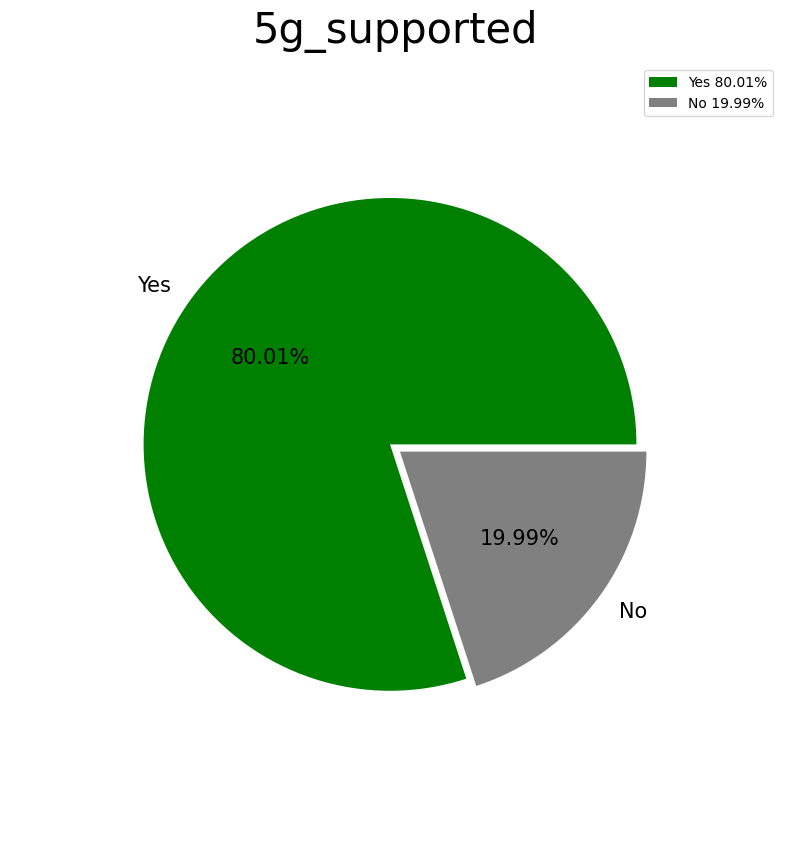

In [39]:
plt.figure(figsize=(15,10))
plt.pie(df['5g_supported'].value_counts().values,labels=df['5g_supported'].value_counts().index,colors=['green','gray'],
        explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('5g_supported',fontsize=30,pad=15)
plt.legend(['Yes 80.01%','No 19.99%'])

plt.xticks()
plt.yticks()
plt.show()

In [40]:
df['os_version'].describe()

count    144899.000000
mean         15.498996
std           1.117781
min          14.000000
25%          15.000000
50%          15.000000
75%          16.000000
max          17.000000
Name: os_version, dtype: float64

In [41]:
df['operating_system'].value_counts()

operating_system
Android    130368
iOS         14531
Name: count, dtype: int64

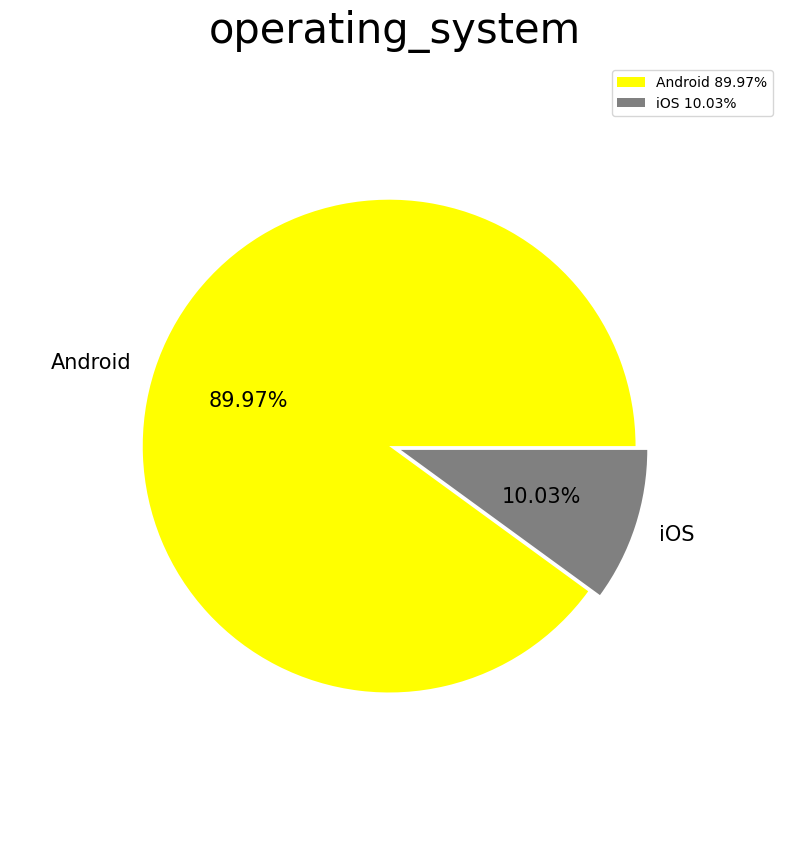

In [42]:
plt.figure(figsize=(15,10))
plt.pie(df['operating_system'].value_counts().values,labels=df['operating_system'].value_counts().index,colors=['yellow','gray'],
        explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('operating_system',fontsize=30,pad=15)
plt.legend(['Android 89.97%','iOS 10.03%'])

plt.xticks()
plt.yticks()
plt.show()

In [43]:
df['processor_brand'].value_counts()

processor_brand
Tensor                29264
Apple A-Series        23295
Helio                 23165
MediaTek Dimensity    23128
Snapdragon            23079
Exynos                22968
Name: count, dtype: int64

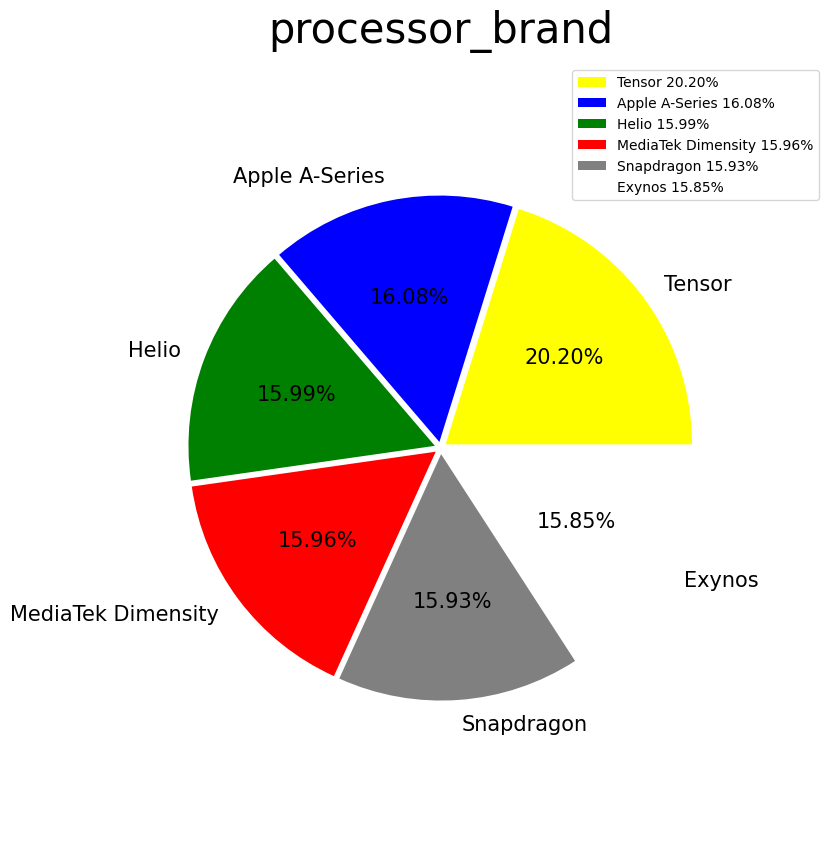

In [44]:
plt.figure(figsize=(15,10))
plt.pie(df['processor_brand'].value_counts().values,labels=df['processor_brand'].value_counts().index,colors=['yellow','blue','green','red','gray','white'],
        explode=[0.02,0.02,0.02,0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('processor_brand',fontsize=30,pad=15)
plt.legend(['Tensor 20.20%','Apple A-Series 16.08%','Helio 15.99%','MediaTek Dimensity 15.96%','Snapdragon 15.93%','Exynos 15.85%'])

plt.xticks()
plt.yticks()
plt.show()

In [45]:
df['panel_type'].value_counts()

panel_type
IPS LCD         36432
OLED            36230
Super AMOLED    36205
AMOLED          36032
Name: count, dtype: int64

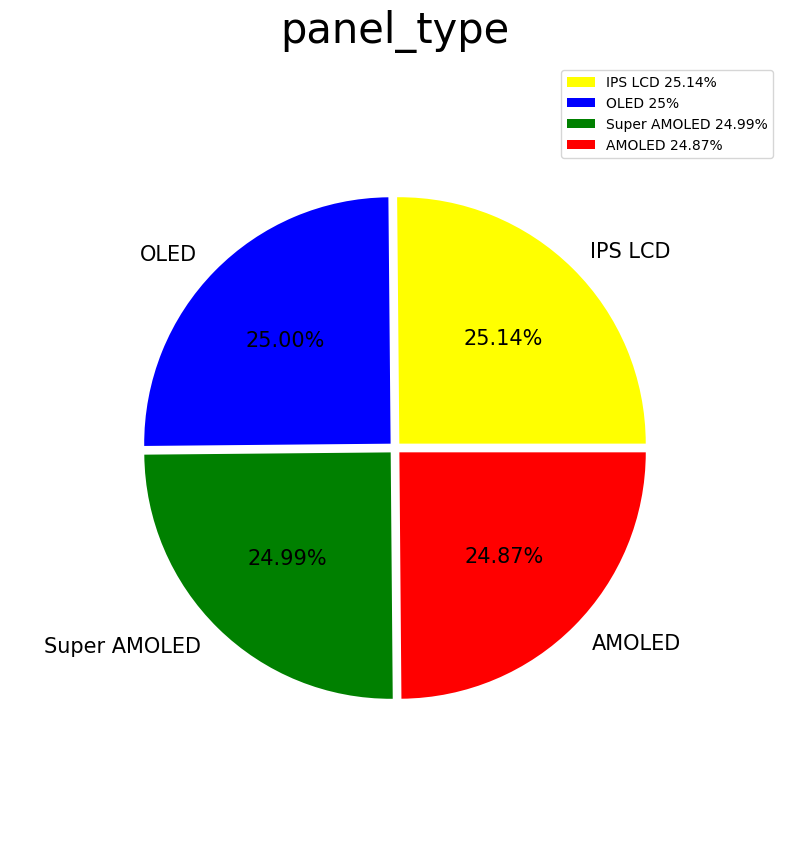

In [46]:
plt.figure(figsize=(15,10))
plt.pie(df['panel_type'].value_counts().values,labels=df['panel_type'].value_counts().index,colors=['yellow','blue','green','red'],
        explode=[0.02,0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('panel_type',fontsize=30,pad=15)
plt.legend(['IPS LCD 25.14%','OLED 25%','Super AMOLED 24.99%','AMOLED 24.87%'])

plt.xticks()
plt.yticks()
plt.show()

In [47]:
df['refresh_rate_hz'].describe()

count    144899.000000
mean        104.392108
std          26.701567
min          60.000000
25%          90.000000
50%         120.000000
75%         120.000000
max         144.000000
Name: refresh_rate_hz, dtype: float64

In [48]:
df['screen_resolution'].value_counts()

screen_resolution
FHD+    86752
QHD+    29048
HD+     21704
4K       7395
Name: count, dtype: int64

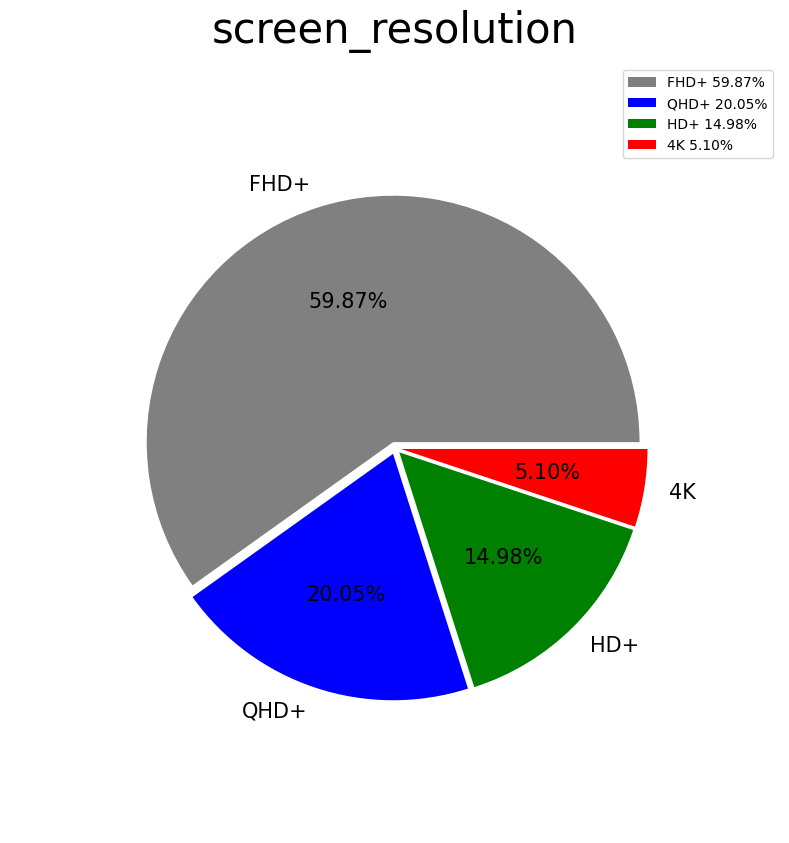

In [49]:
plt.figure(figsize=(15,10))
plt.pie(df['screen_resolution'].value_counts().values,labels=df['screen_resolution'].value_counts().index,colors=['gray','blue','green','red'],
        explode=[0.02,0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('screen_resolution',fontsize=30,pad=15)
plt.legend(['FHD+ 59.87%','QHD+ 20.05%','HD+ 14.98%','4K 5.10%'])

plt.xticks()
plt.yticks()
plt.show()

In [50]:
df['storage_gb'].describe()

count    144899.000000
mean        261.086025
std         221.754004
min          64.000000
25%         128.000000
50%         128.000000
75%         256.000000
max        1024.000000
Name: storage_gb, dtype: float64

In [51]:
df['ram_gb'].describe()

count    144899.000000
mean          9.687700
std           4.645886
min           4.000000
25%           6.000000
50%           8.000000
75%          12.000000
max          24.000000
Name: ram_gb, dtype: float64

In [52]:
df['core_count'].describe()

count    144899.000000
mean          7.495248
std           1.077128
min           4.000000
25%           8.000000
50%           8.000000
75%           8.000000
max           8.000000
Name: core_count, dtype: float64

In [53]:
df['processor_model'].value_counts()

processor_model
Gen_2    36307
Gen_3    36260
Gen_1    36186
Gen_4    36146
Name: count, dtype: int64

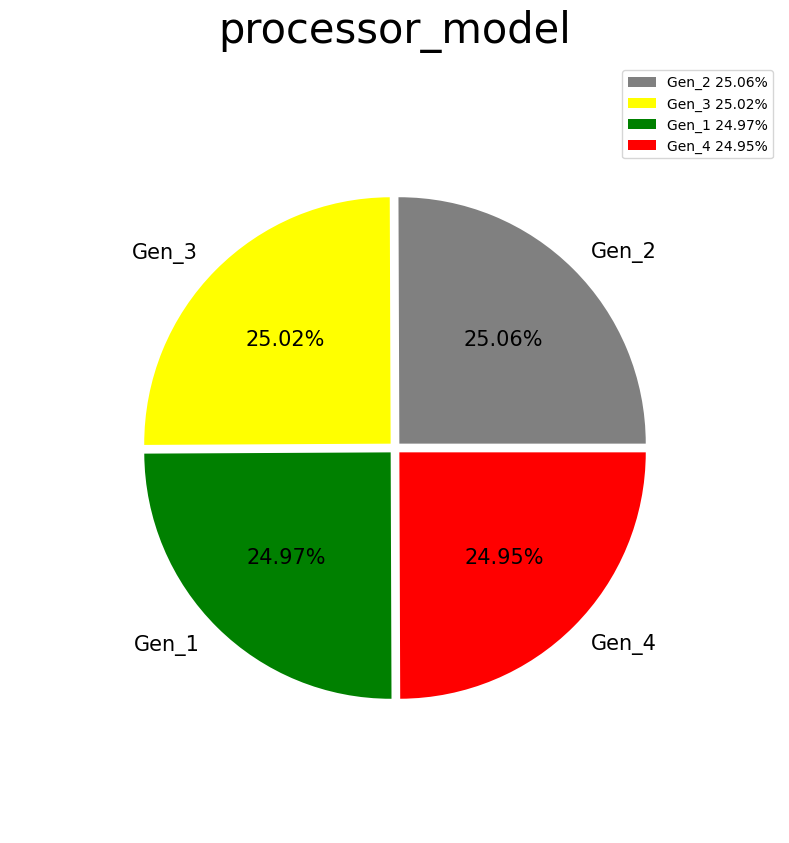

In [54]:
plt.figure(figsize=(15,10))
plt.pie(df['processor_model'].value_counts().values,labels=df['processor_model'].value_counts().index,colors=['gray','yellow','green','red'],
        explode=[0.02,0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('processor_model',fontsize=30,pad=15)
plt.legend(['Gen_2 25.06%','Gen_3 25.02%','Gen_1 24.97%','Gen_4 24.95%'])

plt.xticks()
plt.yticks()
plt.show()

In [55]:
df['num_rear_cameras'].describe()

count    144899.000000
mean          2.501963
std           1.118045
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           4.000000
Name: num_rear_cameras, dtype: float64

In [56]:
df['main_camera_mp'].describe()

count    144899.000000
mean         80.471266
std          60.584761
min          12.000000
25%          48.000000
50%          64.000000
75%         108.000000
max         200.000000
Name: main_camera_mp, dtype: float64

In [57]:
df['card_slot_available'].value_counts()

card_slot_available
No     72520
Yes    72379
Name: count, dtype: int64

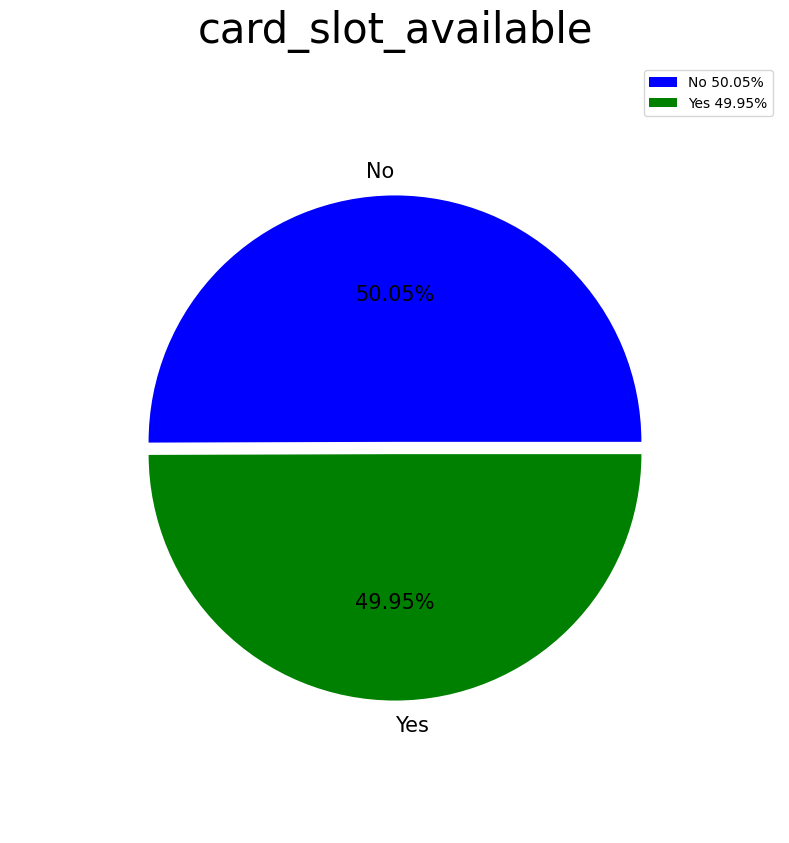

In [58]:
plt.figure(figsize=(15,10))
plt.pie(df['card_slot_available'].value_counts().values,labels=df['card_slot_available'].value_counts().index,colors=['blue','green'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('card_slot_available',fontsize=30,pad=15)
plt.legend(['No 50.05%','Yes 49.95%'])

plt.xticks()
plt.yticks()
plt.show()

In [59]:
df['charging_speed_w'].describe()

count    144899.000000
mean         58.238228
std          36.218638
min          18.000000
25%          25.000000
50%          45.000000
75%         100.000000
max         120.000000
Name: charging_speed_w, dtype: float64

In [60]:
df['battery_capacity_mah'].describe()

count    144899.000000
mean       4997.567271
std         708.683189
min        4000.000000
25%        4500.000000
50%        5000.000000
75%        5500.000000
max        6000.000000
Name: battery_capacity_mah, dtype: float64

In [61]:
df['front_camera_mp'].describe()

count    144899.000000
mean         23.645891
std          15.498294
min           8.000000
25%          12.000000
50%          16.000000
75%          32.000000
max          50.000000
Name: front_camera_mp, dtype: float64

In [62]:
df['body_material'].value_counts()

body_material
Glass/Plastic     29352
Titanium          29309
Glass/Aluminum    28955
Eco-Leather       28702
Plastic           28581
Name: count, dtype: int64

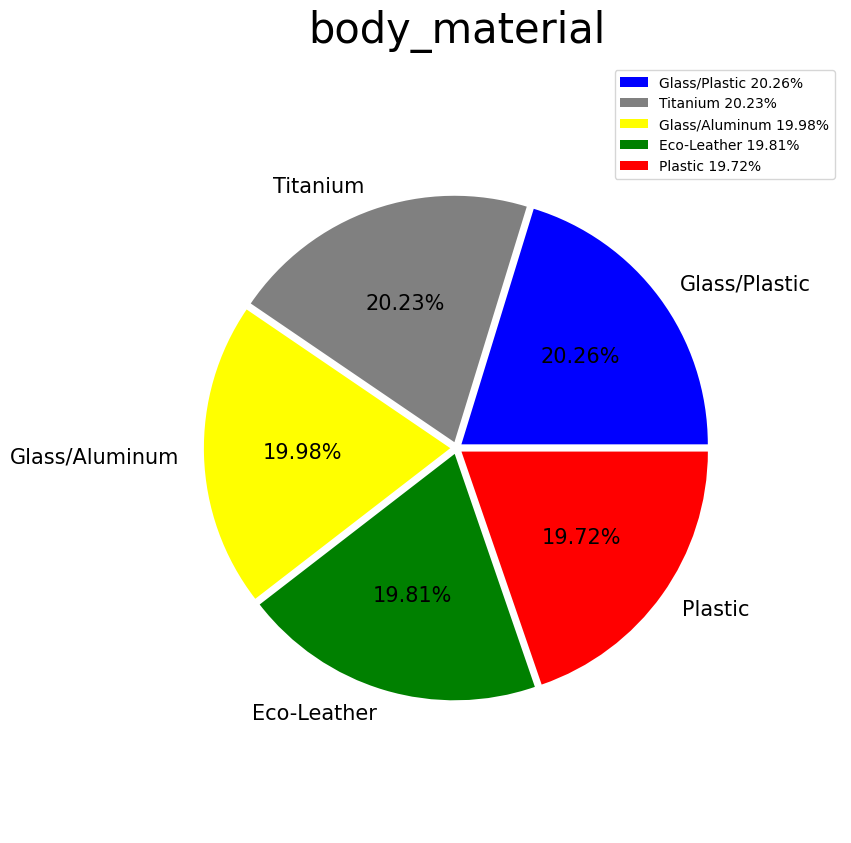

In [63]:
plt.figure(figsize=(15,10))
plt.pie(df['body_material'].value_counts().values,labels=df['body_material'].value_counts().index,colors=['blue','gray','yellow','green','red'],
        explode=[0.02,0.02,0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('body_material',fontsize=30,pad=15)
plt.legend(['Glass/Plastic 20.26%','Titanium 20.23%','Glass/Aluminum 19.98%','Eco-Leather 19.81%','Plastic 19.72%'])

plt.xticks()
plt.yticks()
plt.show()

In [64]:
df['thickness_mm'].describe()

count    144899.000000
mean          8.249081
std           0.721800
min           7.000000
25%           7.600000
50%           8.200000
75%           8.900000
max           9.500000
Name: thickness_mm, dtype: float64

In [65]:
df['weight_grams'].describe()

count    144899.000000
mean        199.534655
std          23.118057
min         160.000000
25%         179.000000
50%         200.000000
75%         220.000000
max         239.000000
Name: weight_grams, dtype: float64

In [66]:
df['wireless_charging'].value_counts()

wireless_charging
No     101593
Yes     43306
Name: count, dtype: int64

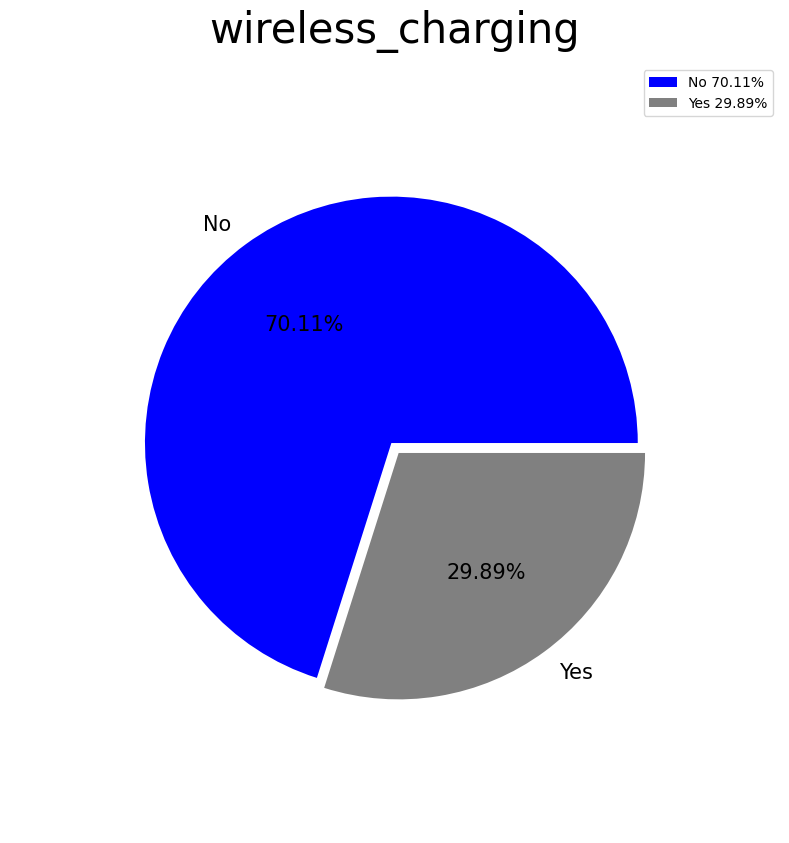

In [67]:
plt.figure(figsize=(15,10))
plt.pie(df['wireless_charging'].value_counts().values,labels=df['wireless_charging'].value_counts().index,colors=['blue','gray'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('wireless_charging',fontsize=30,pad=15)
plt.legend(['No 70.11%','Yes 29.89%'])

plt.xticks()
plt.yticks()
plt.show()

In [68]:
df['region_market'].value_counts()

region_market
Global           29108
Asia             29102
North America    28961
Europe           28935
MEA              28793
Name: count, dtype: int64

In [69]:
df['original_price_usd'].describe()

count    144899.000000
mean        876.111402
std         418.434485
min         150.000000
25%         515.000000
50%         878.000000
75%        1238.000000
max        1599.000000
Name: original_price_usd, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\635128005.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


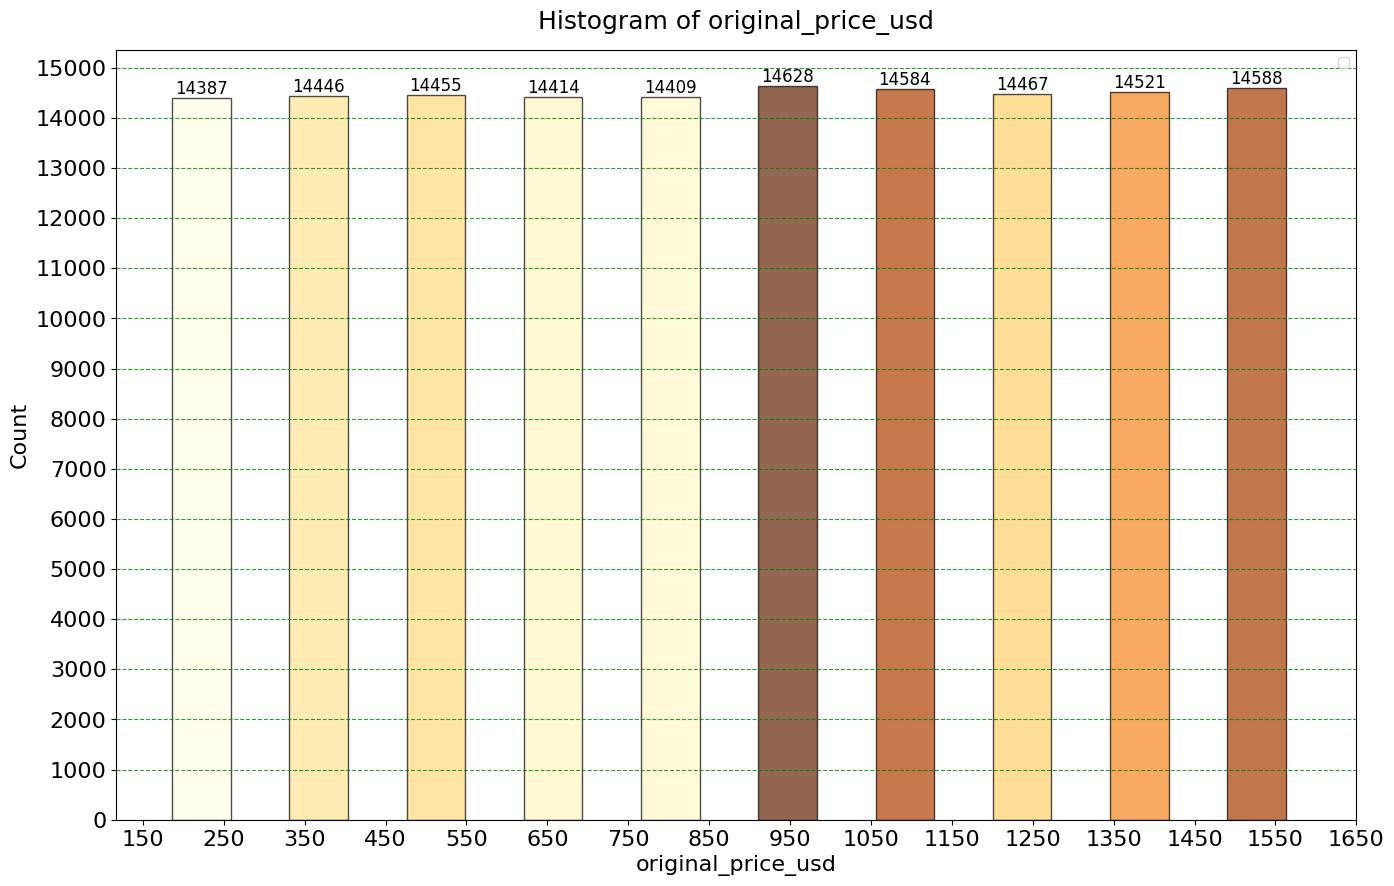

In [70]:
import matplotlib.cm as cm

plt.figure(figsize=(16,10))

cmap = cm.YlOrBr
counts, bins, patches = plt.hist(df['original_price_usd'], bins=10, edgecolor='black',
                                  alpha=0.7, rwidth=0.5)

# إضافة القيم فوق الأعمدة
for i in range(len(counts)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,   # مركز العمود
        counts[i] + 2,               # مكان النص فوق العمود
        str(int(counts[i])),         # القيمة نفسها
        ha='center', va='bottom',
        fontsize=12, color='black')

# تطبيق التدرج اللوني
norm = plt.Normalize(min(counts), max(counts))
for count, patch in zip(counts, patches):
    color = cmap(norm(count))
    patch.set_facecolor(color)  

     

plt.title('Histogram of original_price_usd', fontsize=18, pad=15)
plt.xlabel('original_price_usd', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.xticks(range(150,1700,100) ,fontsize=16)
plt.yticks(range(0,16000,1000),fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.8,color='green')
plt.legend()


plt.show()

In [71]:
df['water_resistance_rating'].value_counts()

water_resistance_rating
IP68    34882
IP53    34732
IP67    34689
Name: count, dtype: int64

In [72]:
df['review_count'].describe()

count    144899.000000
mean      12485.673828
std        7221.045029
min          10.000000
25%        6211.500000
50%       12475.000000
75%       18751.000000
max       24999.000000
Name: review_count, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\864801993.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


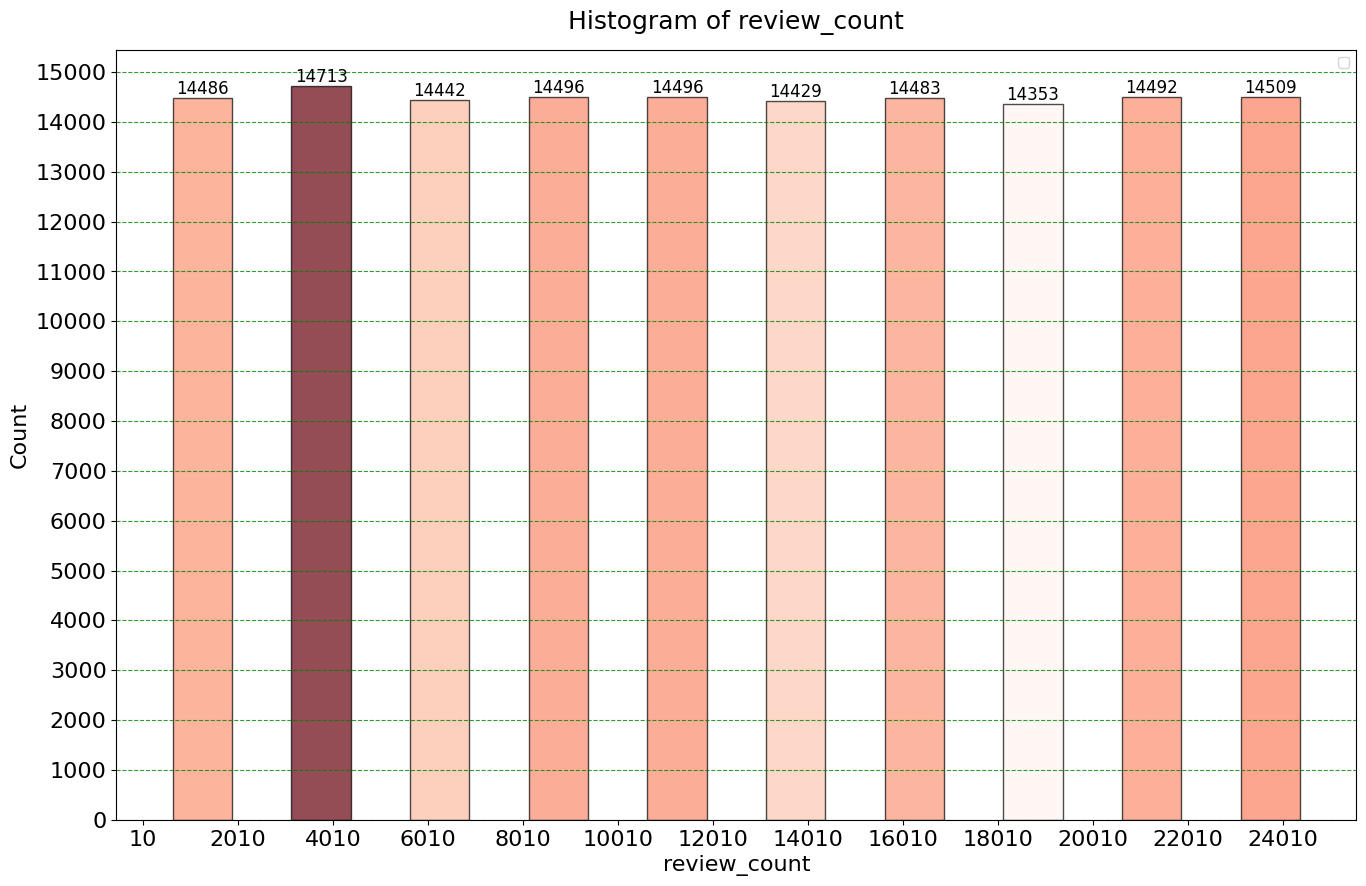

In [73]:
import matplotlib.cm as cm

plt.figure(figsize=(16,10))

cmap = cm.Reds
counts, bins, patches = plt.hist(df['review_count'], bins=10, edgecolor='black',
                                  alpha=0.7, rwidth=0.5)

# إضافة القيم فوق الأعمدة
for i in range(len(counts)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,   # مركز العمود
        counts[i] + 2,               # مكان النص فوق العمود
        str(int(counts[i])),         # القيمة نفسها
        ha='center', va='bottom',
        fontsize=12, color='black')

# تطبيق التدرج اللوني
norm = plt.Normalize(min(counts), max(counts))
for count, patch in zip(counts, patches):
    color = cmap(norm(count))
    patch.set_facecolor(color)  

     

plt.title('Histogram of review_count', fontsize=18, pad=15)
plt.xlabel('review_count', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.xticks( range(10,26000,2000),fontsize=16)
plt.yticks(range(0,16000,1000),fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.8,color='green')
plt.legend()


plt.show()

In [74]:
df['user_rating'].describe()

count    144899.000000
mean          4.246412
std           0.426931
min           3.500000
25%           3.900000
50%           4.200000
75%           4.600000
max           5.000000
Name: user_rating, dtype: float64

In [75]:
df['stock_availability'].describe()

count    144899.000000
mean       2502.392894
std        1443.060064
min           0.000000
25%        1256.000000
50%        2503.000000
75%        3756.000000
max        4999.000000
Name: stock_availability, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\2708268692.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


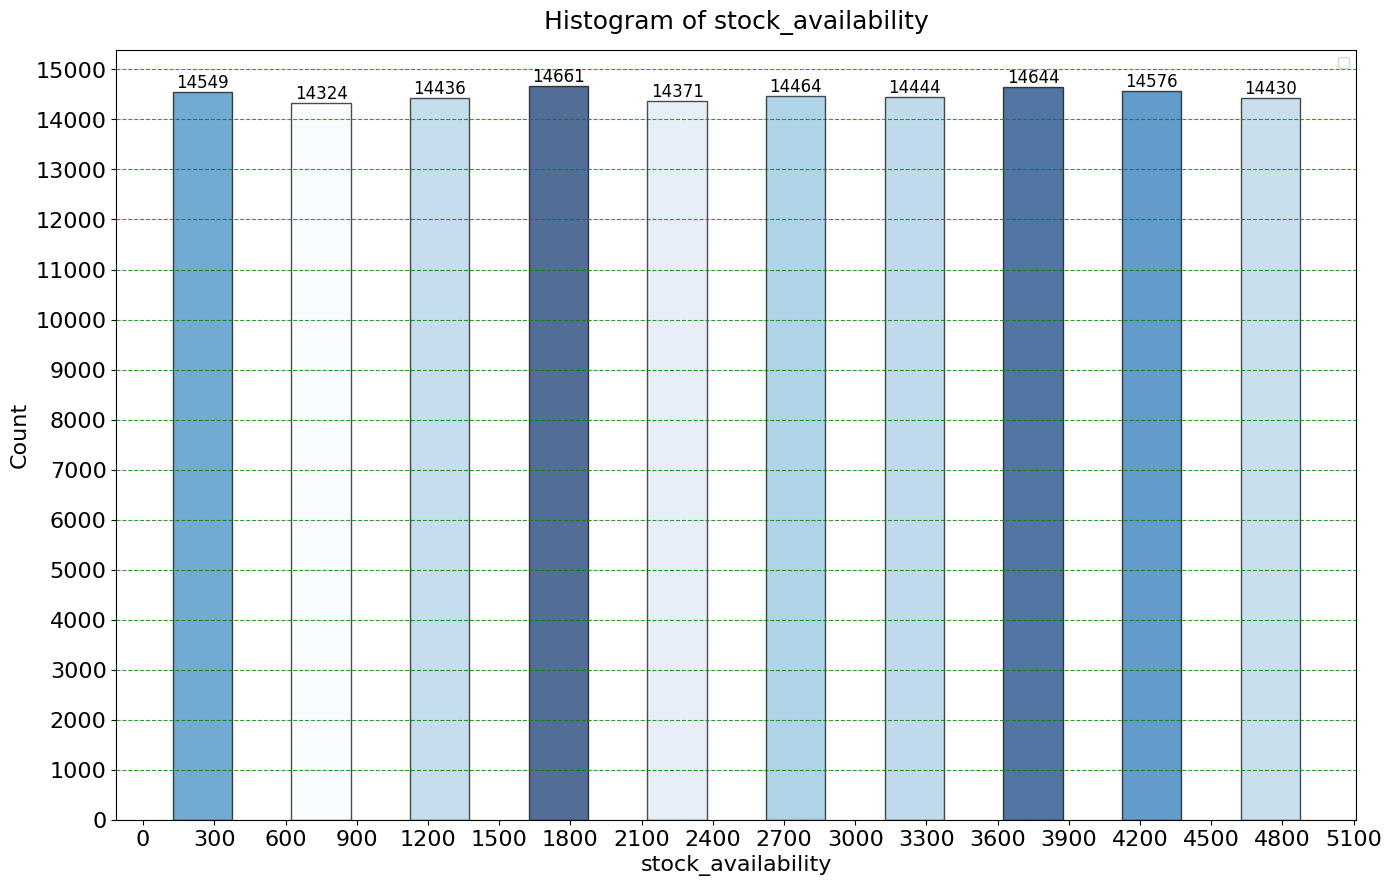

In [76]:
import matplotlib.cm as cm

plt.figure(figsize=(16,10))

cmap = cm.Blues
counts, bins, patches = plt.hist(df['stock_availability'], bins=10, edgecolor='black',
                                  alpha=0.7, rwidth=0.5)

# إضافة القيم فوق الأعمدة
for i in range(len(counts)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,   # مركز العمود
        counts[i] + 2,               # مكان النص فوق العمود
        str(int(counts[i])),         # القيمة نفسها
        ha='center', va='bottom',
        fontsize=12, color='black')

# تطبيق التدرج اللوني
norm = plt.Normalize(min(counts), max(counts))
for count, patch in zip(counts, patches):
    color = cmap(norm(count))
    patch.set_facecolor(color)  

     

plt.title('Histogram of stock_availability', fontsize=18, pad=15)
plt.xlabel('stock_availability', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.xticks( range(0,5180,300),fontsize=16)
plt.yticks( range(0,16000,1000),fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.8,color='green')
plt.legend()


plt.show()

In [77]:
df['discounted_price_usd'].describe()

count    144899.000000
mean        744.541723
std         352.621465
min         113.100000
25%         447.730000
50%         741.980000
75%        1035.615000
max        1515.550000
Name: discounted_price_usd, dtype: float64

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\2615957614.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


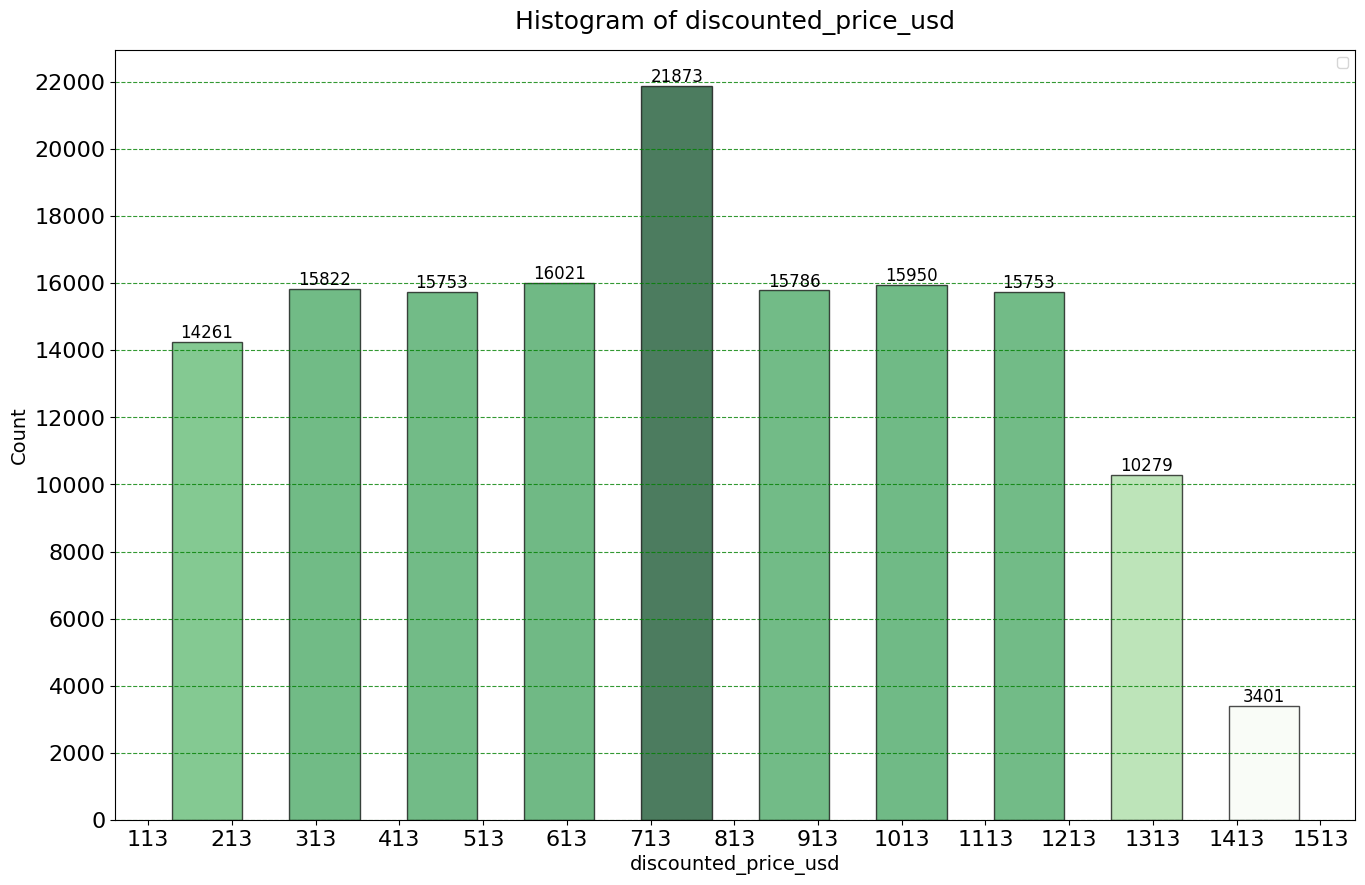

In [78]:
import matplotlib.cm as cm

plt.figure(figsize=(16,10))

cmap = cm.Greens
counts, bins, patches = plt.hist(df['discounted_price_usd'], bins=10, edgecolor='black',
                                  alpha=0.7, rwidth=0.6)

# إضافة القيم فوق الأعمدة
for i in range(len(counts)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,   # مركز العمود
        counts[i] + 2,               # مكان النص فوق العمود
        str(int(counts[i])),         # القيمة نفسها
        ha='center', va='bottom',
        fontsize=12, color='black')

# تطبيق التدرج اللوني
norm = plt.Normalize(min(counts), max(counts))
for count, patch in zip(counts, patches):
    color = cmap(norm(count))
    patch.set_facecolor(color)  

     

plt.title('Histogram of discounted_price_usd', fontsize=18, pad=15)
plt.xlabel('discounted_price_usd', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks( range(113,1600,100),fontsize=16)
plt.yticks( range(0,24000,2000),fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.8,color='green')
plt.legend()


plt.show()

#### **Bivariate Analysis**

# Corrlation

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144899 entries, 0 to 149679
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   brand                    144899 non-null  object 
 1   model                    144899 non-null  object 
 2   marketing_name           144899 non-null  object 
 3   release_year             144899 non-null  int64  
 4   release_month            144899 non-null  int64  
 5   operating_system         144899 non-null  object 
 6   os_version               144899 non-null  int64  
 7   5g_supported             144899 non-null  object 
 8   screen_size_inches       144899 non-null  float64
 9   screen_resolution        144899 non-null  object 
 10  refresh_rate_hz          144899 non-null  int64  
 11  panel_type               144899 non-null  object 
 12  processor_brand          144899 non-null  object 
 13  processor_model          144899 non-null  object 
 14  core_coun

In [80]:
df.columns

Index(['brand', 'model', 'marketing_name', 'release_year', 'release_month',
       'operating_system', 'os_version', '5g_supported', 'screen_size_inches',
       'screen_resolution', 'refresh_rate_hz', 'panel_type', 'processor_brand',
       'processor_model', 'core_count', 'ram_gb', 'storage_gb',
       'card_slot_available', 'main_camera_mp', 'num_rear_cameras',
       'front_camera_mp', 'battery_capacity_mah', 'charging_speed_w',
       'wireless_charging', 'weight_grams', 'thickness_mm', 'body_material',
       'water_resistance_rating', 'original_price_usd', 'region_market',
       'stock_availability', 'user_rating', 'review_count',
       'discounted_price_usd'],
      dtype='object')

In [81]:
df[['release_year','release_month','screen_size_inches','refresh_rate_hz','core_count','ram_gb','storage_gb','main_camera_mp',
    'num_rear_cameras','front_camera_mp','battery_capacity_mah','charging_speed_w','thickness_mm','original_price_usd',
    'user_rating','review_count','discounted_price_usd']]

,release_year,release_month,screen_size_inches,refresh_rate_hz,core_count,ram_gb,storage_gb,main_camera_mp,num_rear_cameras,front_camera_mp,battery_capacity_mah,charging_speed_w,thickness_mm,original_price_usd,user_rating,review_count,discounted_price_usd
0,2024,5,5.6,90,8,8,128,48,1,12,4500,33,8.0,1048,5.0,14790,797.82
1,2025,12,6.7,90,8,12,256,108,3,50,6000,100,8.2,1367,4.8,13151,1063.94
2,2024,12,6.3,120,6,6,256,50,3,12,4000,18,7.5,909,3.9,10828,812.76
3,2025,5,6.6,90,6,8,128,48,1,12,6000,45,7.2,968,4.6,3598,825.46
4,2026,12,5.6,60,8,6,64,64,4,8,6000,25,7.7,1434,4.8,20041,1257.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149675,2026,1,6.6,120,4,12,128,200,2,8,6000,33,8.3,880,3.8,2020,803.03
149676,2023,5,6.4,120,8,16,64,50,1,12,5000,45,8.1,204,4.4,19221,153.33
149677,2025,1,5.7,60,6,8,128,12,4,32,4000,45,7.2,929,4.5,12155,828.48
149678,2025,7,6.1,60,8,8,256,48,2,32,4500,67,7.1,219,4.7,1197,199.81


In [82]:
corr=df[['release_year','release_month','screen_size_inches','refresh_rate_hz','core_count','ram_gb','storage_gb','main_camera_mp',
    'num_rear_cameras','front_camera_mp','battery_capacity_mah','charging_speed_w','thickness_mm','original_price_usd',
    'user_rating','review_count','discounted_price_usd']]

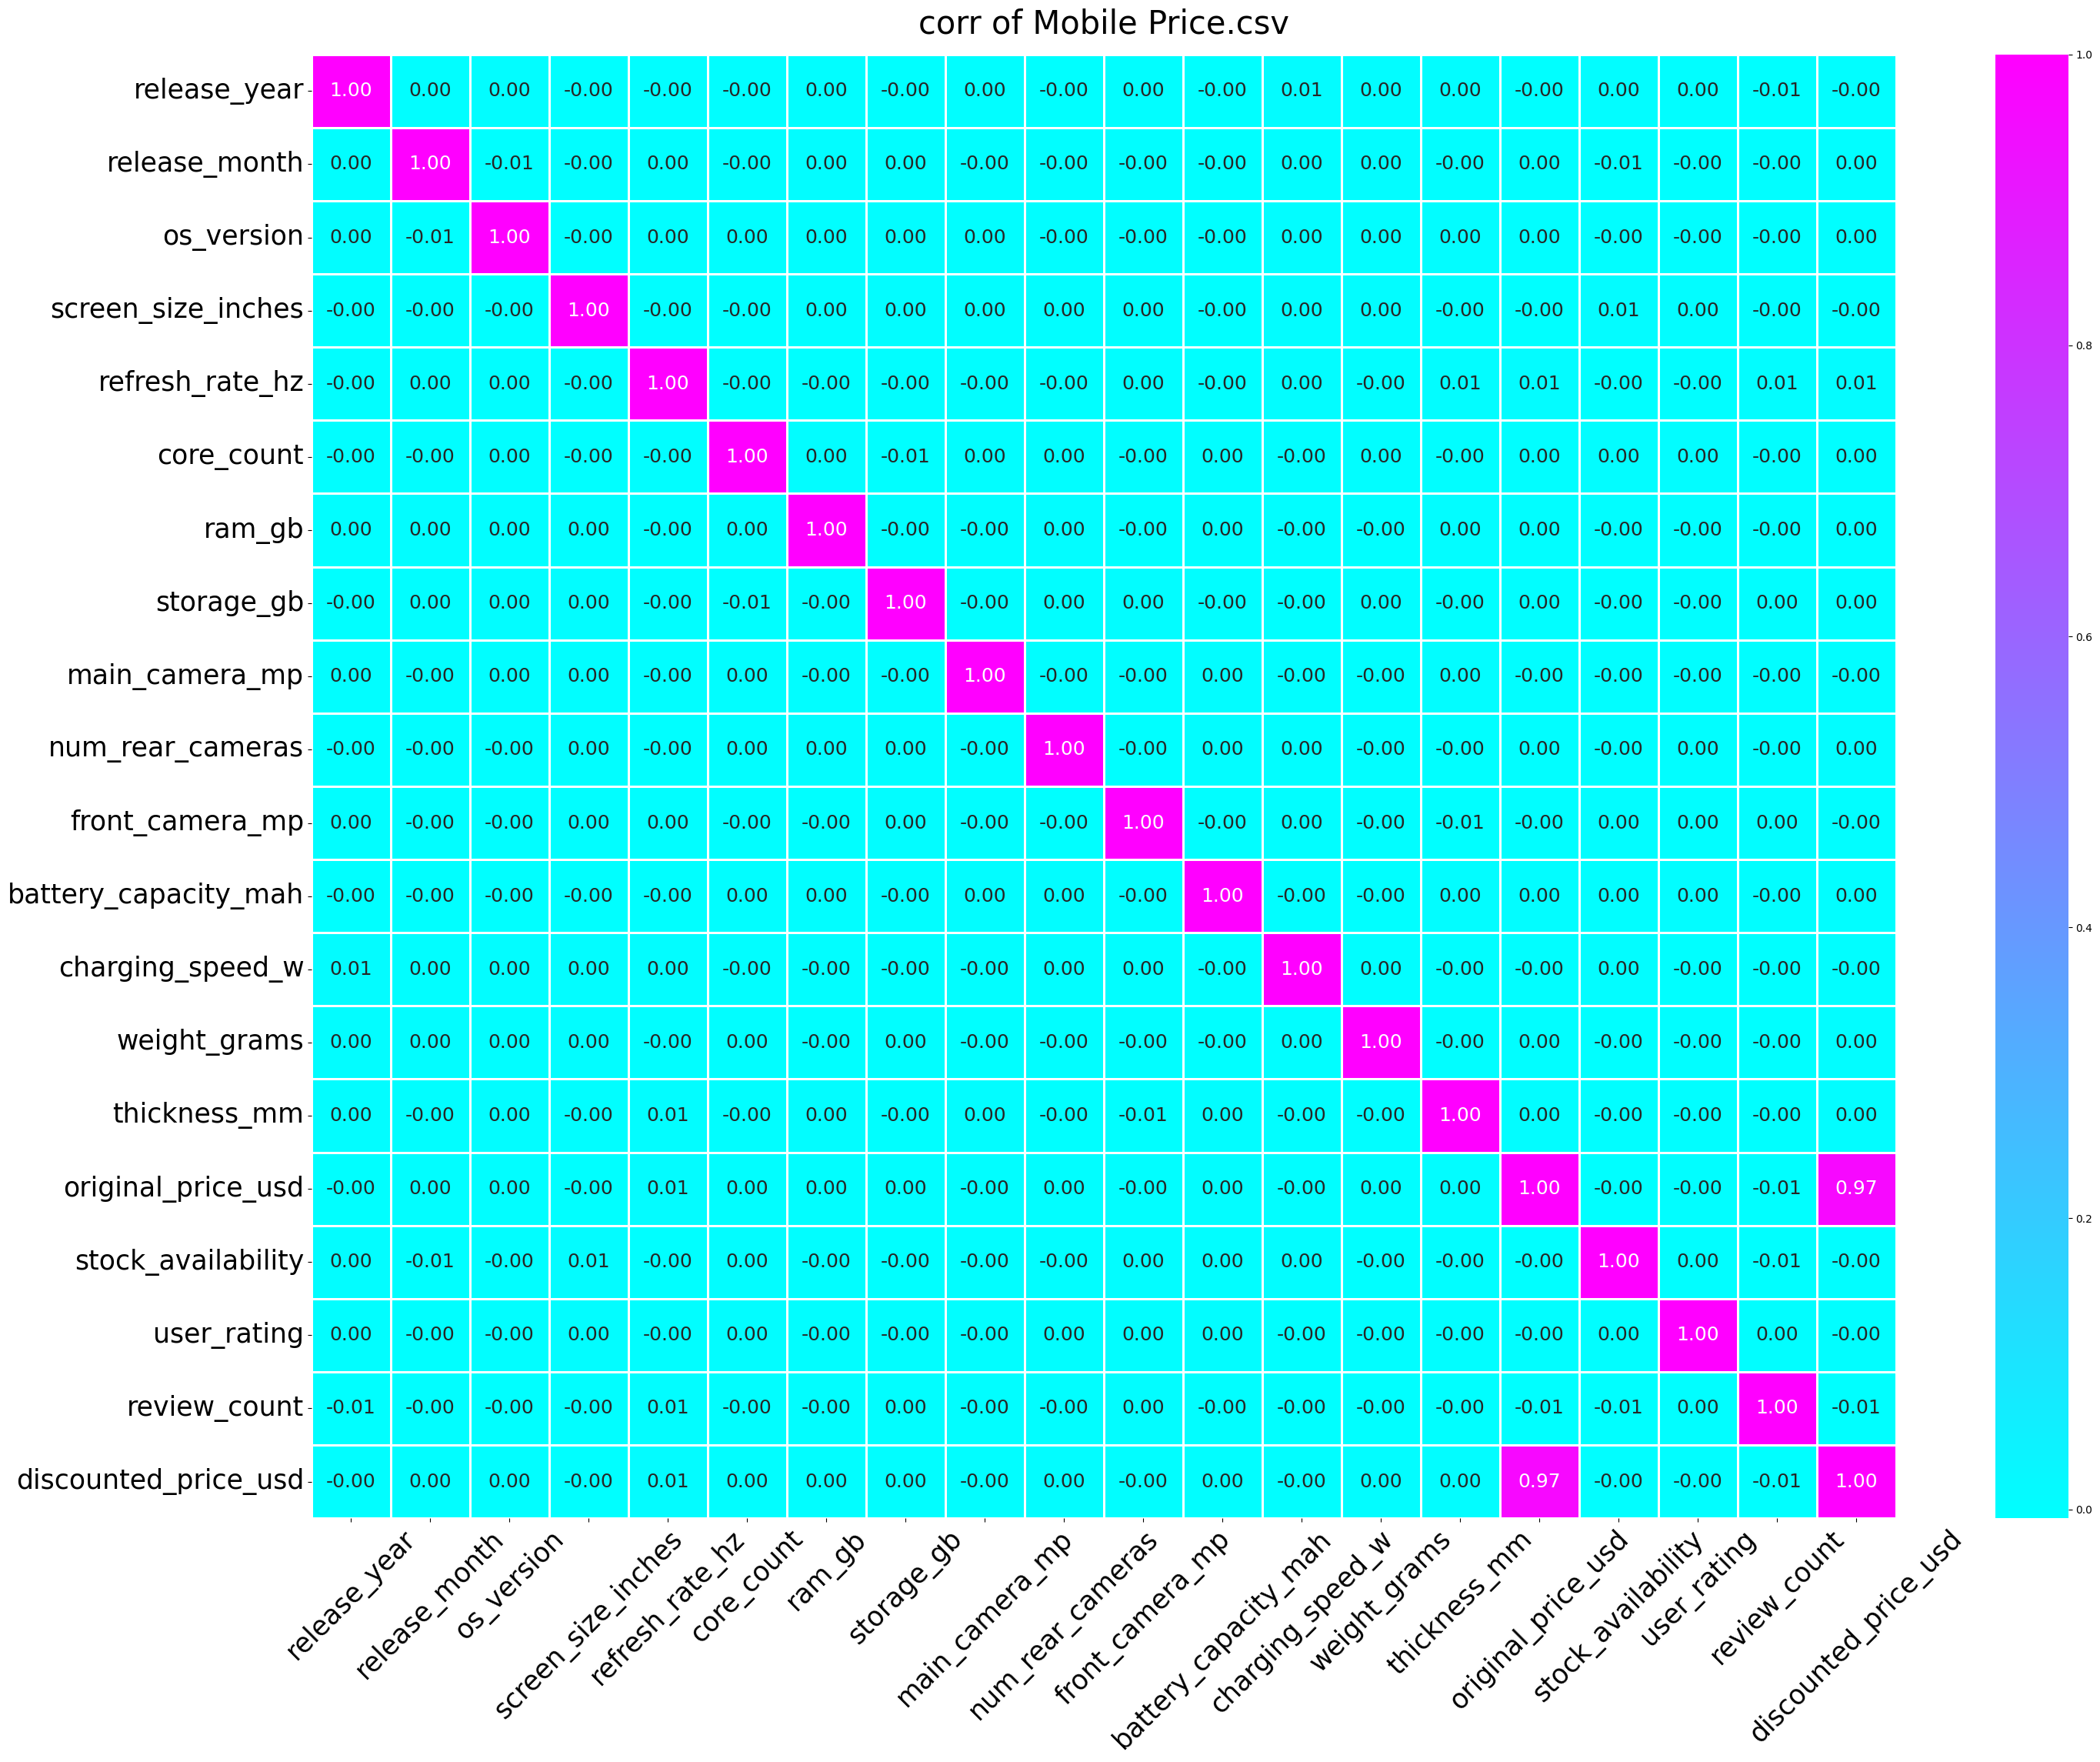

In [83]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(30,23))
sns.heatmap(corr,cmap='cool',annot=True,edgecolor='yellow',linewidths=0.8,fmt='.2f',annot_kws={"size": 18})
plt.title('corr of Mobile Price.csv',fontsize=30,pad=20)
plt.xticks(rotation=45,fontsize=25)
plt.yticks(rotation=0,fontsize=25)

plt.tight_layout()
plt.show()


#  thickness_mm + discounted_price_usd

In [84]:
df.groupby(['thickness_mm'])['discounted_price_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
thickness_mm,,,,,,,,
7.0,2897.0,751.168098,350.479889,113.57,465.4200,741.98,1045.1800,1513.96
7.1,5863.0,745.260873,352.171285,113.63,449.2050,741.98,1038.6850,1505.88
7.2,5705.0,741.560491,355.441277,115.01,435.5700,741.98,1038.5000,1512.15
7.3,5800.0,746.860886,349.970842,116.02,455.8350,741.98,1039.0900,1511.33
7.4,5769.0,741.976216,348.664501,115.27,451.4100,741.98,1026.6600,1494.94
7.5,5789.0,746.142446,353.582193,117.19,443.9500,741.98,1043.8200,1515.16
7.6,5816.0,741.700825,350.511622,116.17,455.4850,741.98,1026.5925,1504.51
7.7,5837.0,740.018114,353.574040,114.41,443.2100,741.98,1034.1400,1500.61
7.8,5877.0,740.616832,352.780061,117.06,441.5900,741.98,1032.7200,1511.86


C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\1787443601.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues", len(thickness))   # Greens أو أي تدرج آخر
C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\1787443601.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='thickness_mm', y='discounted_price_usd', data=df,width=0.5,


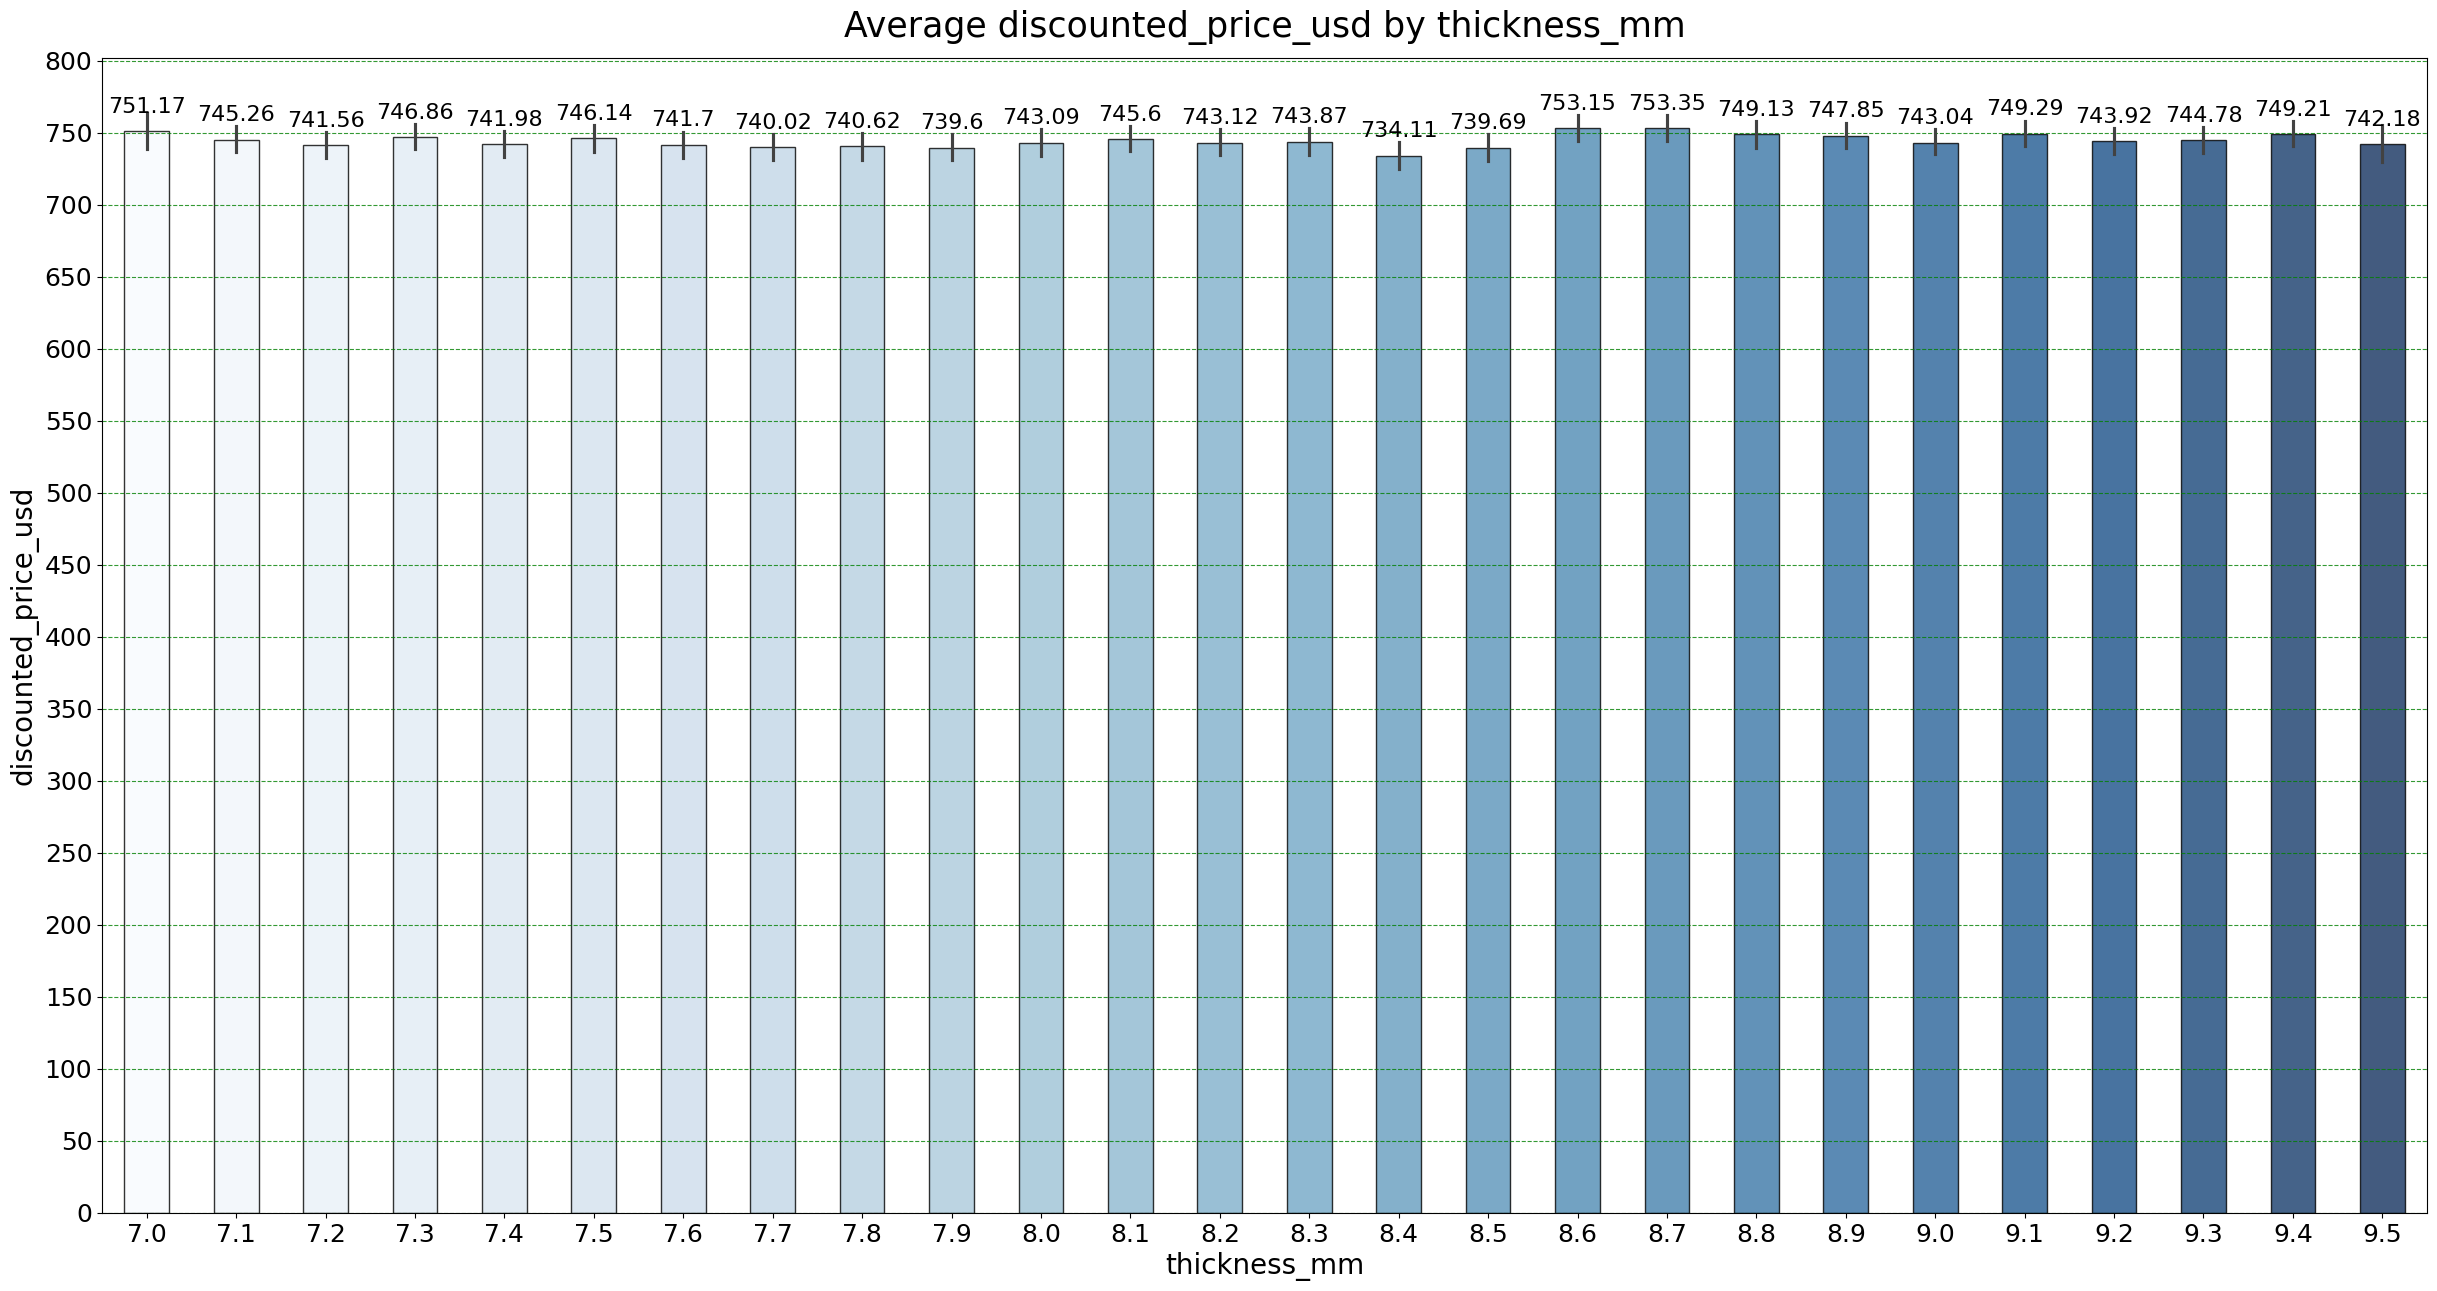

In [85]:


plt.figure(figsize=(30,15))

# نحدد عدد الألوان المطلوبة حسب عدد البراندات
thickness = df['thickness_mm'].unique()
cmap = cm.get_cmap("Blues", len(thickness))   # Greens أو أي تدرج آخر
palette = [cmap(i) for i in range(len(thickness))]

# رسم الأعمدة باستخدام التدرج اللوني
ax = sns.barplot(x='thickness_mm', y='discounted_price_usd', data=df,width=0.5,
                 palette=palette, alpha=0.8, edgecolor='black')

# إضافة القيم فوق الأعمدة
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height() + 10,
            round(p.get_height(), 2),
            ha='center', va='bottom', fontsize=16, color='black')

plt.title('Average discounted_price_usd by thickness_mm', fontsize=25, pad=15)
plt.xlabel('thickness_mm', fontsize=20)
plt.ylabel('discounted_price_usd', fontsize=20)
plt.xticks( fontsize=18)
plt.yticks(range(0,850,50),fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.8, color='green')
plt.show()


# original_price_usd + discounted_price_usd

In [86]:
df.groupby(['original_price_usd'])['discounted_price_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
original_price_usd,,,,,,,,
150,100.0,141.464900,86.584380,113.10,122.9700,131.035,136.7100,741.98
151,120.0,142.474583,96.830371,113.57,119.0100,125.970,135.1775,741.98
152,86.0,186.333372,179.168351,114.41,122.6125,132.100,137.2475,741.98
153,102.0,160.479412,132.972345,114.78,122.1375,131.540,139.7300,741.98
154,110.0,151.748364,115.451133,115.99,123.6800,129.070,136.2775,741.98
...,...,...,...,...,...,...,...,...
1595,109.0,1325.781376,149.397102,741.98,1241.8000,1335.120,1434.5400,1511.86
1596,94.0,1338.966809,179.718964,741.98,1298.1675,1362.110,1456.9875,1515.55
1597,108.0,1371.038611,86.052556,1208.11,1294.2075,1375.665,1445.6275,1512.15


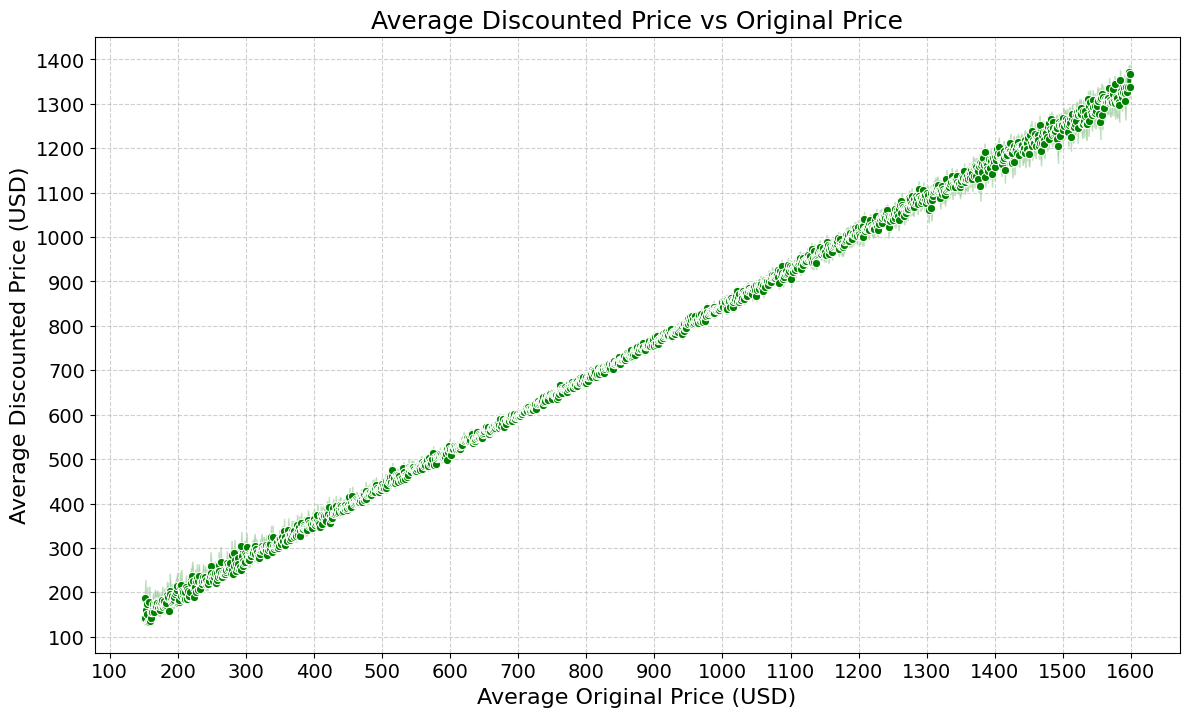

In [87]:



plt.figure(figsize=(14,8))
sns.lineplot(x='original_price_usd', y='discounted_price_usd', data=df, estimator='mean', color='green', marker='o')
plt.title('Average Discounted Price vs Original Price', fontsize=18)
plt.xlabel('Average Original Price (USD)', fontsize=16)
plt.ylabel('Average Discounted Price (USD)', fontsize=16)
plt.xticks(range(100,1700,100),fontsize=14)
plt.yticks(range(100,1500,100),fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Ram_gb + Discounted_Price_usd

In [88]:
df.groupby(['ram_gb'])['discounted_price_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
ram_gb,,,,,,,,
4,14468.0,747.673778,353.282465,113.80,450.2750,741.98,1040.0800,1511.86
6,21867.0,744.851018,353.219986,115.31,446.3150,741.98,1037.6850,1513.46
8,57978.0,742.378246,352.594112,113.57,446.1675,741.98,1033.0450,1515.55
12,28930.0,746.767634,350.477309,113.10,452.2950,741.98,1037.2000,1512.15
16,14508.0,744.669957,353.985347,114.41,448.5400,741.98,1035.5125,1507.29
24,7148.0,745.535036,355.549060,115.47,441.9100,741.98,1037.4500,1513.01


C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\2537125059.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("gray", len(ram))   # Greens أو أي تدرج آخر
C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\2537125059.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='ram_gb', y='discounted_price_usd', data=df,width=0.3,


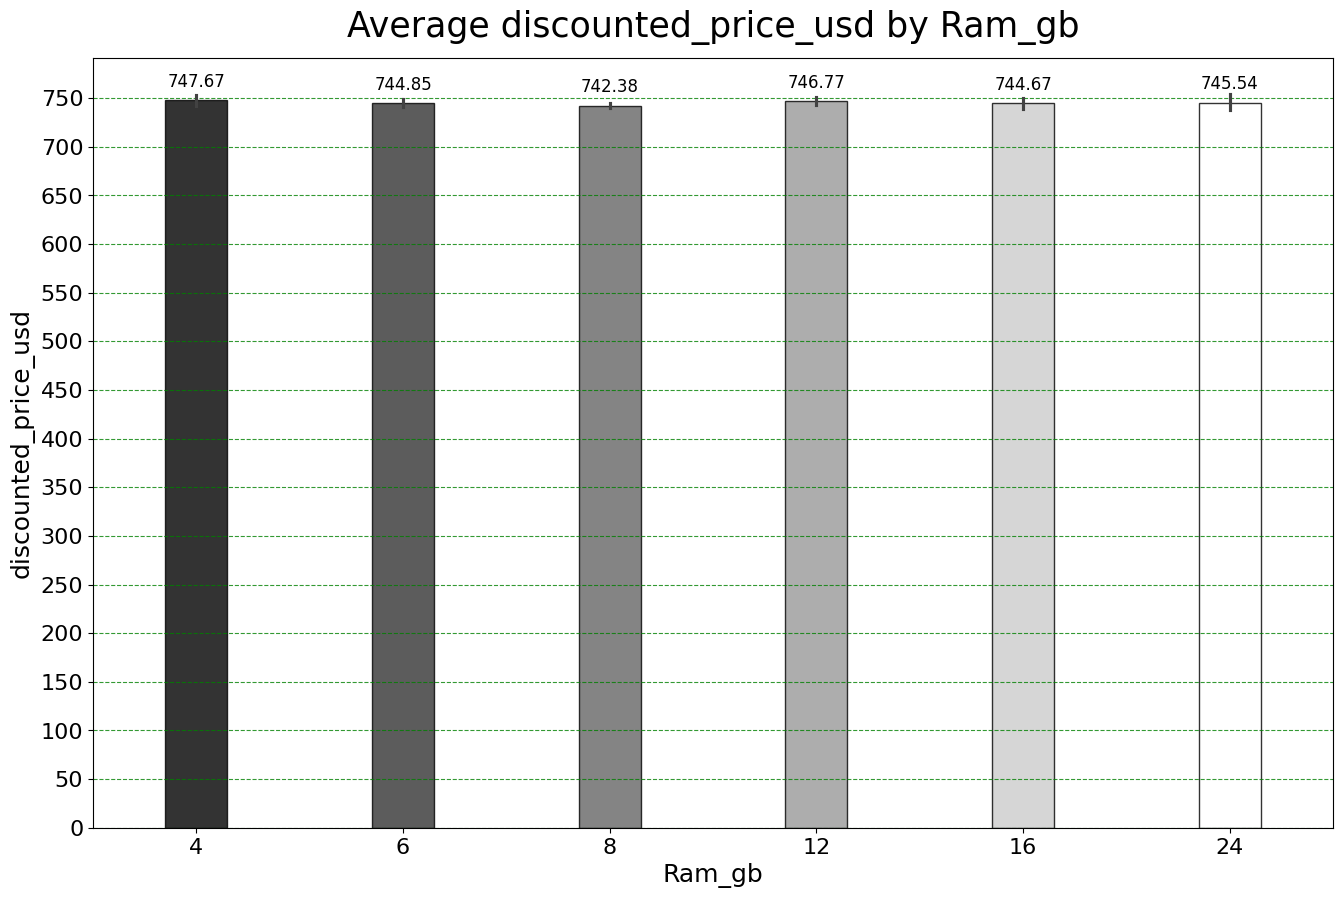

In [89]:


plt.figure(figsize=(16,10))

# نحدد عدد الألوان المطلوبة حسب عدد البراندات
ram= df['ram_gb'].unique()
cmap = cm.get_cmap("gray", len(ram))   # Greens أو أي تدرج آخر
palette = [cmap(i) for i in range(len(ram))]

# رسم الأعمدة باستخدام التدرج اللوني
ax = sns.barplot(x='ram_gb', y='discounted_price_usd', data=df,width=0.3,
                 palette=palette, alpha=0.8, edgecolor='black')

# إضافة القيم فوق الأعمدة
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height() + 10,
            round(p.get_height(), 2),
            ha='center', va='bottom', fontsize=12, color='black')

plt.title('Average discounted_price_usd by Ram_gb', fontsize=25, pad=15)
plt.xlabel('Ram_gb', fontsize=18)
plt.ylabel('discounted_price_usd', fontsize=18)
plt.xticks( fontsize=16)
plt.yticks(range(0,800,50),fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.8, color='green')
plt.show()


In [90]:
import ipywidgets as widgets
from IPython.display import display

# نجيب القيم الفريدة للـ RAM
ram= df['ram_gb'].unique()

# نعمل Dropdown
ram_selector = widgets.Dropdown(options=ram, description='RAM:')
display(ram_selector)

# دالة التحديث
def update_chart(change):
    selected_value = change['new']   # هنا بنجيب القيمة المختارة من الـ Dropdown
    filtered_df = df[df['ram_gb'] == selected_value]
    
    plt.figure(figsize=(10,6))
    sns.barplot(x='ram_gb', y='discounted_price_usd', data=filtered_df, palette='Greens')
    plt.title(f'Average Discounted Price for RAM {selected_value} GB')
    plt.show()

# ربط الدالة بالـ widget
ram_selector.observe(update_chart, names='value')


Dropdown(description='RAM:', options=(np.int64(8), np.int64(12), np.int64(6), np.int64(4), np.int64(16), np.in…

# Brand + Discounted_Price_usd

In [91]:
df.groupby(['brand'])['discounted_price_usd'].value_counts()

brand   discounted_price_usd
Apple   741.98                  626
        1059.47                   4
        1239.26                   4
        166.86                    3
        168.67                    3
                               ... 
Xiaomi  1504.86                   1
        1506.95                   1
        1511.33                   1
        1512.16                   1
        1513.46                   1
Name: count, Length: 130163, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\1242119420.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues", len(brands))   # Greens أو أي تدرج آخر
C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\1242119420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='brand', y='discounted_price_usd', data=df,width=0.5,


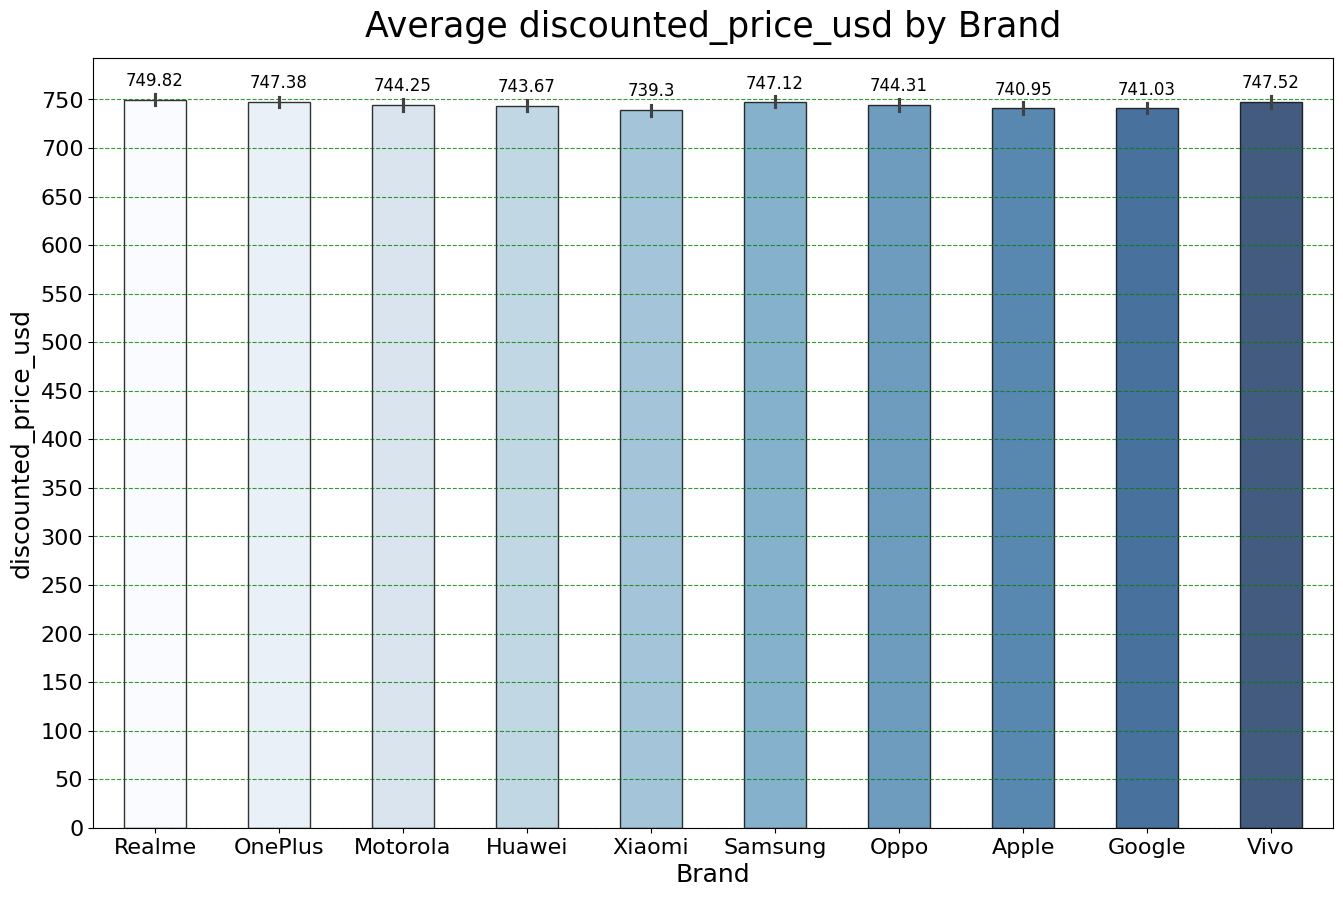

In [92]:


plt.figure(figsize=(16,10))

# نحدد عدد الألوان المطلوبة حسب عدد البراندات
brands = df['brand'].unique()
cmap = cm.get_cmap("Blues", len(brands))   # Greens أو أي تدرج آخر
palette = [cmap(i) for i in range(len(brands))]

# رسم الأعمدة باستخدام التدرج اللوني
ax = sns.barplot(x='brand', y='discounted_price_usd', data=df,width=0.5,
                 palette=palette, alpha=0.8, edgecolor='black')

# إضافة القيم فوق الأعمدة
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height() + 10,
            round(p.get_height(), 2),
            ha='center', va='bottom', fontsize=12, color='black')

plt.title('Average discounted_price_usd by Brand', fontsize=25, pad=15)
plt.xlabel('Brand', fontsize=18)
plt.ylabel('discounted_price_usd', fontsize=18)
plt.xticks( fontsize=16)
plt.yticks(range(0,800,50),fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.8, color='green')
plt.show()


# Brand + Original_Price_Usd

In [93]:
df.groupby(['brand'])['original_price_usd'].value_counts()

brand   original_price_usd
Apple   914                   21
        1142                  19
        1394                  19
        163                   18
        351                   18
                              ..
Xiaomi  1233                   2
        1336                   2
        1442                   2
        1535                   2
        908                    1
Name: count, Length: 14500, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\3131986437.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greens", len(brands))   # Greens أو أي تدرج آخر
C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\3131986437.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='brand', y='original_price_usd', data=df,width=0.5,


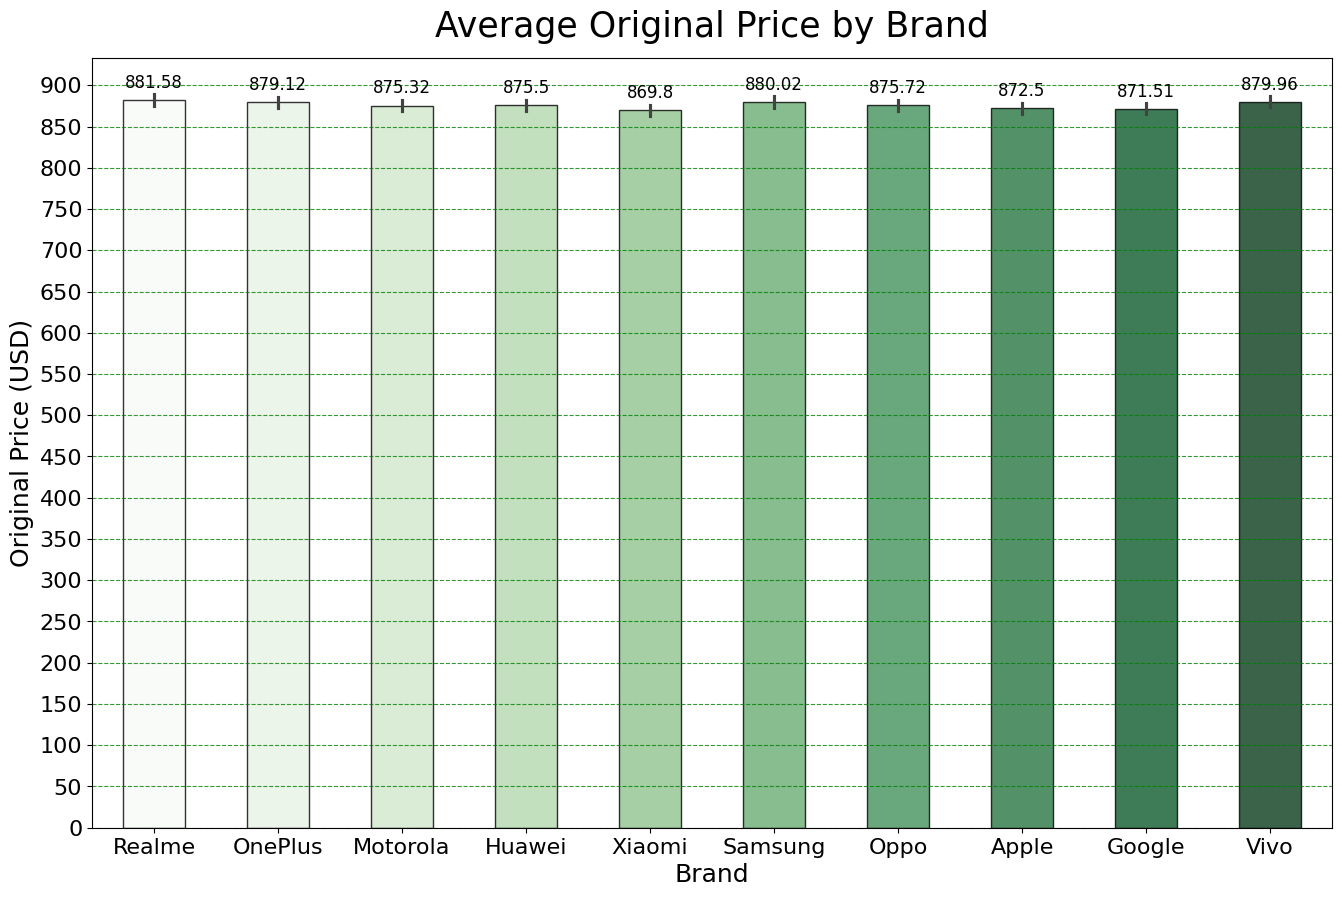

In [94]:


plt.figure(figsize=(16,10))

# نحدد عدد الألوان المطلوبة حسب عدد البراندات
brands = df['brand'].unique()
cmap = cm.get_cmap("Greens", len(brands))   # Greens أو أي تدرج آخر
palette = [cmap(i) for i in range(len(brands))]

# رسم الأعمدة باستخدام التدرج اللوني
ax = sns.barplot(x='brand', y='original_price_usd', data=df,width=0.5,
                 palette=palette, alpha=0.8, edgecolor='black')

# إضافة القيم فوق الأعمدة
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height() + 10,
            round(p.get_height(), 2),
            ha='center', va='bottom', fontsize=12, color='black')

plt.title('Average Original Price by Brand', fontsize=25, pad=15)
plt.xlabel('Brand', fontsize=18)
plt.ylabel('Original Price (USD)', fontsize=18)
plt.xticks( fontsize=16)
plt.yticks( range(0,950,50),fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.8, color='green')
plt.show()


In [95]:
import ipywidgets as widgets
from IPython.display import display

brands = df['brand'].unique()
brand_selector = widgets.Dropdown(options=brands, description='Brand:')
display(brand_selector)

def update_chart(change):
    selected_brand = change['new']
    filtered_df = df[df['brand'] == selected_brand]
    sns.barplot(x='brand', y='original_price_usd', data=filtered_df, palette='Greens')
    plt.title(f'Average Original Price for {selected_brand}')
    plt.show()

brand_selector.observe(update_chart, names='value')


Dropdown(description='Brand:', options=('Realme', 'OnePlus', 'Motorola', 'Huawei', 'Xiaomi', 'Samsung', 'Oppo'…

# multivariate analysis

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144899 entries, 0 to 149679
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   brand                    144899 non-null  object 
 1   model                    144899 non-null  object 
 2   marketing_name           144899 non-null  object 
 3   release_year             144899 non-null  int64  
 4   release_month            144899 non-null  int64  
 5   operating_system         144899 non-null  object 
 6   os_version               144899 non-null  int64  
 7   5g_supported             144899 non-null  object 
 8   screen_size_inches       144899 non-null  float64
 9   screen_resolution        144899 non-null  object 
 10  refresh_rate_hz          144899 non-null  int64  
 11  panel_type               144899 non-null  object 
 12  processor_brand          144899 non-null  object 
 13  processor_model          144899 non-null  object 
 14  core_coun

# brand + model + discounted_price_usd

In [97]:
df.groupby(['brand','model'])['discounted_price_usd'].describe()

count        mean         std     min       25%      50%  \
brand  model                                                                 
Apple  Model_100   12.0  728.160833  447.095321  131.17  379.7050  611.820   
       Model_101   24.0  750.011250  353.801666  282.68  463.0600  623.970   
       Model_102   20.0  669.165000  371.871167  132.02  435.8625  589.360   
       Model_103   18.0  608.284444  378.548192  222.46  297.2625  475.765   
       Model_104   16.0  686.851250  342.771685  125.58  524.2425  715.730   
...                 ...         ...         ...     ...       ...      ...   
Xiaomi Model_994   13.0  713.448462  252.463842  123.01  601.5800  741.980   
       Model_995   20.0  760.767000  389.661851  163.13  355.2525  773.490   
       Model_996   15.0  836.868000  352.466394  234.11  595.5300  871.830   
       Model_997   11.0  824.186364  384.648611  186.68  685.4850  860.530   
       Model_998   10.0  790.300000  390.834214  255.08  411.1650  807.435   

                        75%      max  
brand  model                          
Apple  Model_100  1189.5400  1303.43  
       Model_101  1114.5500  1386.42  
       Model_102   867.4400  1469.59  
       Model_103   790.3850  1315.70  
       Model_104   835.1975  1492.85  
...                     ...      ...  
Xiaomi Model_994   886.3600  1079.03  
       Model_995  1042.1200  1484.31  
       Model_996  1101.4850  1410.31  
       Model_997   902.0000  1456.97  
       Model_998  1115.7025  1313.02  

[8990 rows x 8 columns]

# Brand + Original_Price_usd + Discounted_Price_usd

In [98]:
df.groupby(['brand','original_price_usd'])['discounted_price_usd'].describe()

count         mean         std      min        25%  \
brand  original_price_usd                                                       
Apple  150                   6.0   136.801667    3.126707   132.96   134.1350   
       151                  10.0   122.444000    5.454772   115.51   118.7025   
       152                   9.0   198.600000  203.854268   123.21   127.2100   
       153                   7.0   134.191429   10.280281   119.49   127.1250   
       154                  15.0   168.079333  158.968905   117.23   121.5950   
...                          ...          ...         ...      ...        ...   
Xiaomi 1595                 13.0  1365.938462   91.768906  1197.94  1288.3300   
       1596                  8.0  1408.223750   83.313360  1282.64  1340.8850   
       1597                 12.0  1343.888333   97.630505  1231.29  1260.5275   
       1598                  7.0  1408.734286   90.824394  1308.93  1320.2800   
       1599                  6.0  1399.038333  106.480877  1236.47  1335.9725   

                                50%        75%      max  
brand  original_price_usd                                
Apple  150                  137.425   139.0800   140.33  
       151                  123.515   123.8800   134.29  
       152                  132.690   136.0800   741.98  
       153                  134.500   143.0250   145.05  
       154                  125.990   131.9950   741.98  
...                             ...        ...      ...  
Xiaomi 1595                1386.400  1424.7200  1494.28  
       1596                1441.415  1470.7325  1495.63  
       1597                1325.295  1428.0000  1488.22  
       1598                1424.540  1487.8900  1511.33  
       1599                1418.525  1478.7275  1513.46  

[14500 rows x 8 columns]

# Dashboard

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144899 entries, 0 to 149679
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   brand                    144899 non-null  object 
 1   model                    144899 non-null  object 
 2   marketing_name           144899 non-null  object 
 3   release_year             144899 non-null  int64  
 4   release_month            144899 non-null  int64  
 5   operating_system         144899 non-null  object 
 6   os_version               144899 non-null  int64  
 7   5g_supported             144899 non-null  object 
 8   screen_size_inches       144899 non-null  float64
 9   screen_resolution        144899 non-null  object 
 10  refresh_rate_hz          144899 non-null  int64  
 11  panel_type               144899 non-null  object 
 12  processor_brand          144899 non-null  object 
 13  processor_model          144899 non-null  object 
 14  core_coun

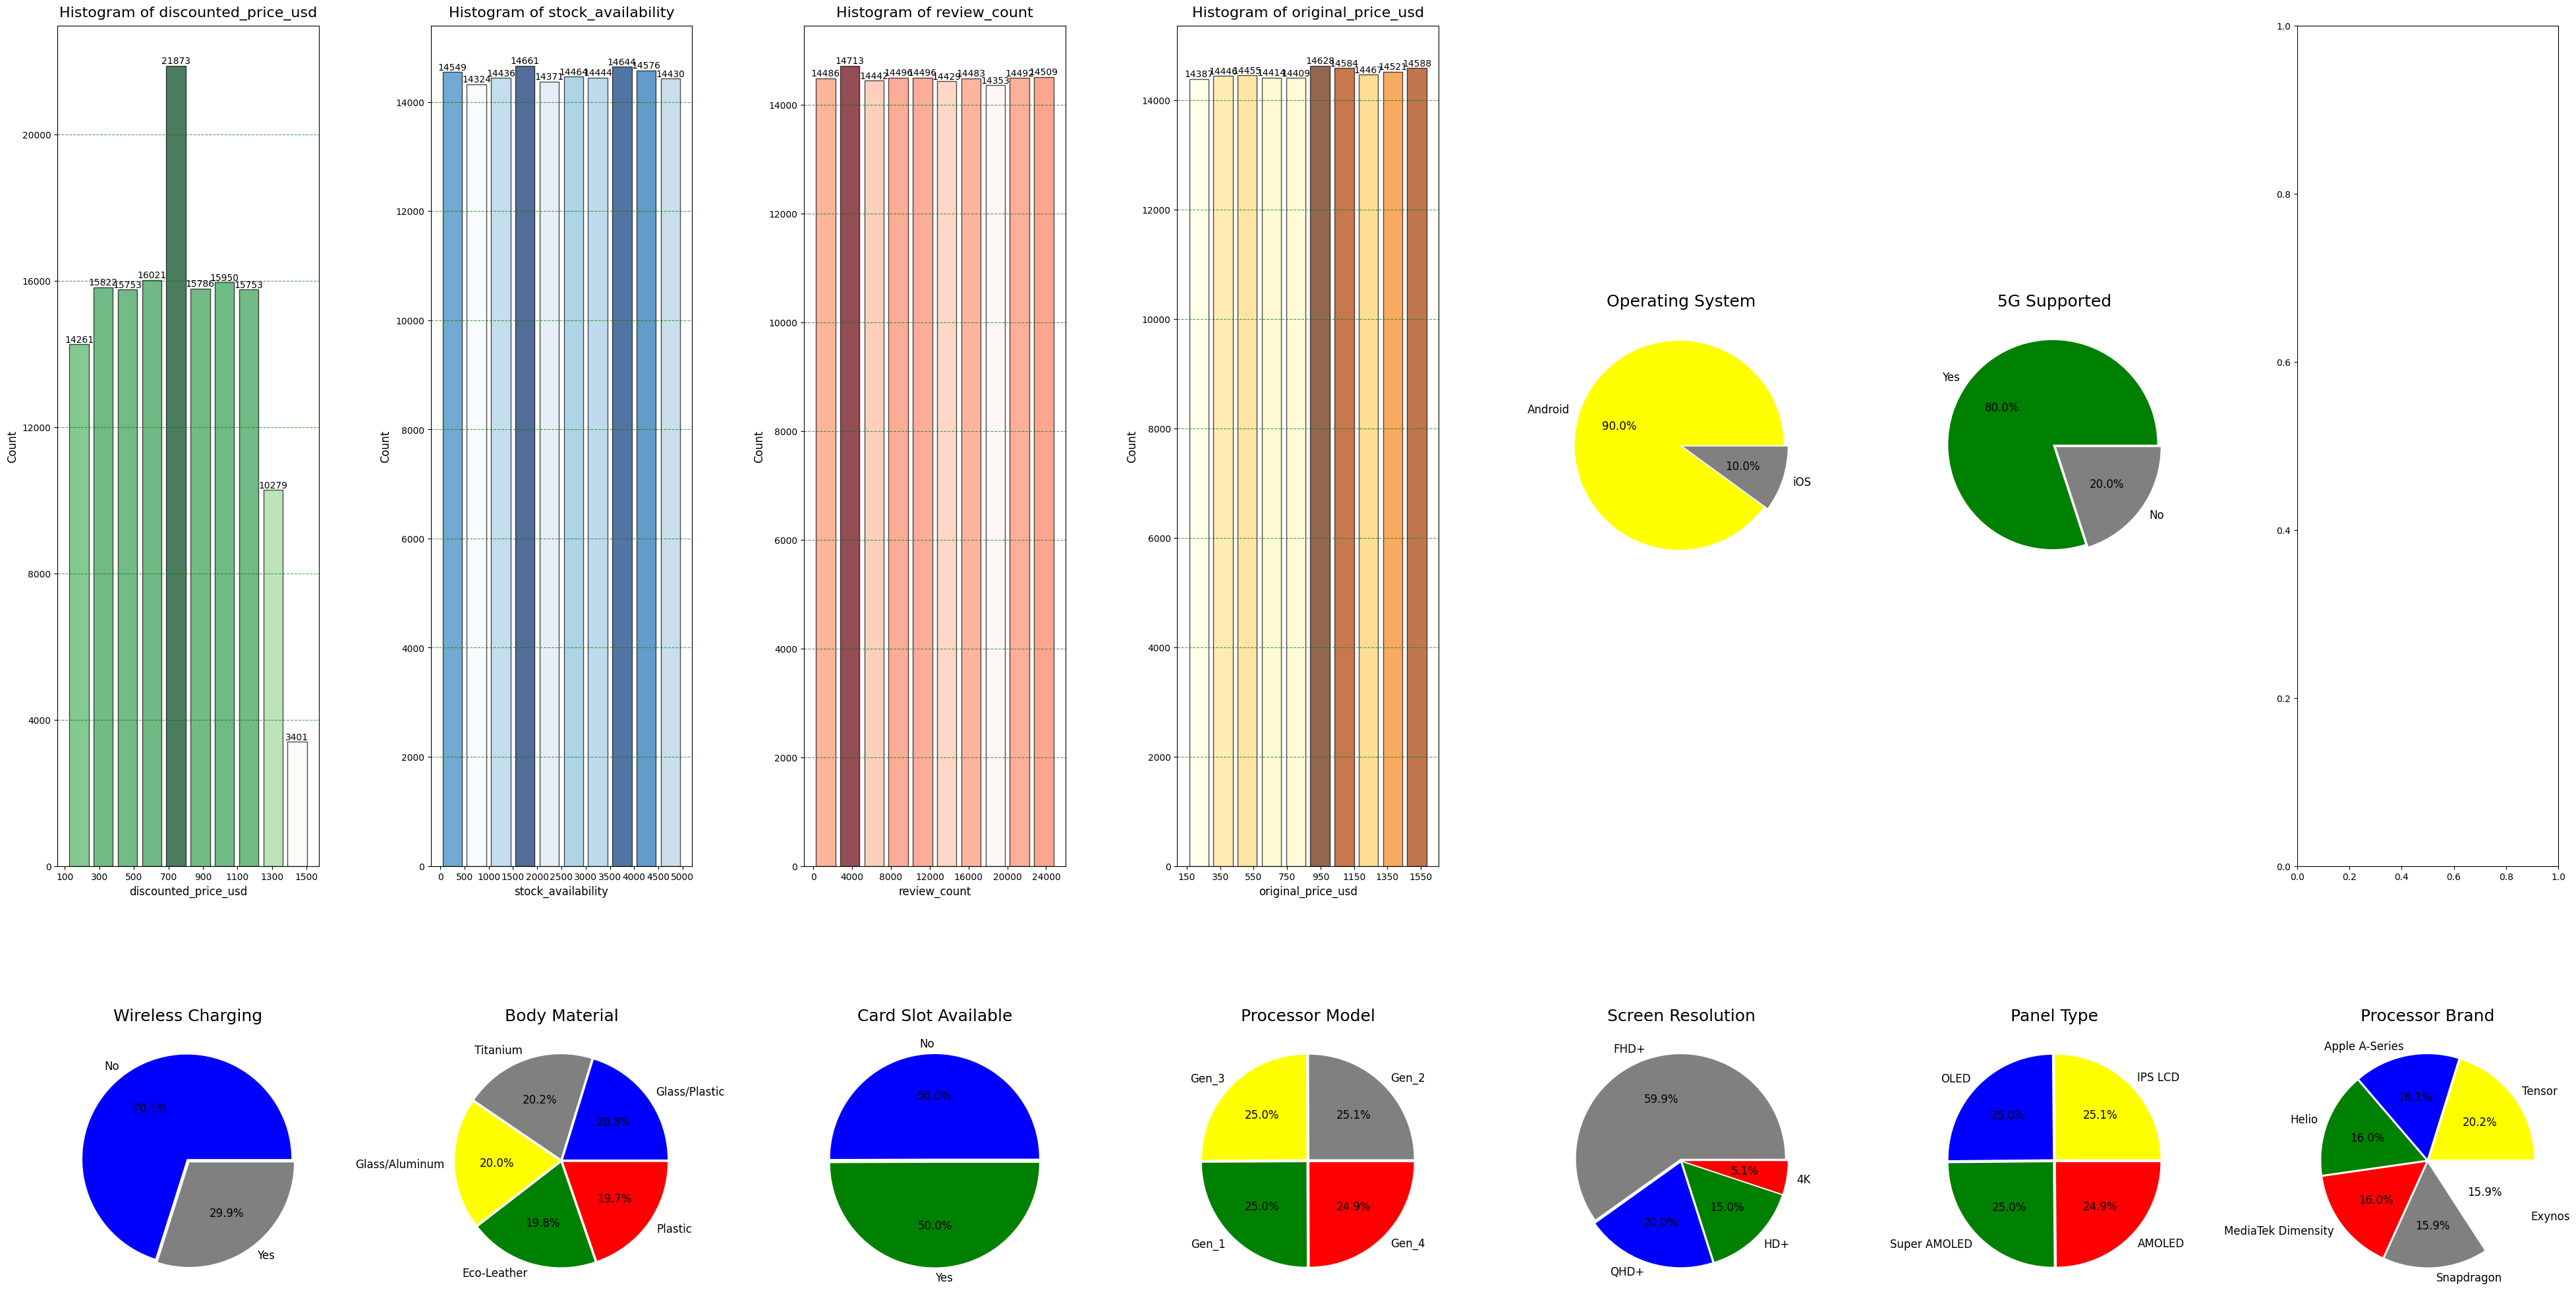

In [100]:
fig, axes = plt.subplots(2, 7, figsize=(40, 25))
plt.tight_layout(pad=8.0)

# subplot 1: discounted_price_usd
ax1 = axes[0,0]
cmap = cm.Greens
counts, bins, patches = ax1.hist(df['discounted_price_usd'], bins=10, edgecolor='black',
                                  alpha=0.7, rwidth=0.8)
for i in range(len(counts)):
    ax1.text((bins[i] + bins[i+1]) / 2, counts[i] + 2, str(int(counts[i])),
             ha='center', va='bottom', fontsize=10, color='black')
norm = plt.Normalize(min(counts), max(counts))
for count, patch in zip(counts, patches):
    patch.set_facecolor(cmap(norm(count)))
ax1.set_title('Histogram of discounted_price_usd', fontsize=16, pad=10)
ax1.set_xlabel('discounted_price_usd', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xticks(range(100,1600,200))
ax1.set_yticks(range(0,24000,4000))
ax1.grid(axis='y', linestyle='--', alpha=0.7, color='green')

# subplot 2: stock_availability
ax2 = axes[0,1]
cmap = cm.Blues
counts, bins, patches = ax2.hist(df['stock_availability'], bins=10, edgecolor='black',
                                  alpha=0.7, rwidth=0.8)
for i in range(len(counts)):
    ax2.text((bins[i] + bins[i+1]) / 2, counts[i] + 2, str(int(counts[i])),
             ha='center', va='bottom', fontsize=10, color='black')
norm = plt.Normalize(min(counts), max(counts))
for count, patch in zip(counts, patches):
    patch.set_facecolor(cmap(norm(count)))
ax2.set_title('Histogram of stock_availability', fontsize=16, pad=10)
ax2.set_xlabel('stock_availability', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_xticks(range(0,5200,500))
ax2.set_yticks(range(0,16000,2000))
ax2.grid(axis='y', linestyle='--', alpha=0.7, color='green')

# subplot 3: review_count
ax3 = axes[0,2]
cmap = cm.Reds
counts, bins, patches = ax3.hist(df['review_count'], bins=10, edgecolor='black',
                                  alpha=0.7, rwidth=0.8)
for i in range(len(counts)):
    ax3.text((bins[i] + bins[i+1]) / 2, counts[i] + 2, str(int(counts[i])),
             ha='center', va='bottom', fontsize=10, color='black')
norm = plt.Normalize(min(counts), max(counts))
for count, patch in zip(counts, patches):
    patch.set_facecolor(cmap(norm(count)))
ax3.set_title('Histogram of review_count', fontsize=16, pad=10)
ax3.set_xlabel('review_count', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_xticks(range(0,26000,4000))
ax3.set_yticks(range(0,16000,2000))
ax3.grid(axis='y', linestyle='--', alpha=0.7, color='green')

# subplot 4: original_price_usd
ax4 = axes[0,3]
cmap = cm.YlOrBr
counts, bins, patches = ax4.hist(df['original_price_usd'], bins=10, edgecolor='black',
                                  alpha=0.7, rwidth=0.8)
for i in range(len(counts)):
    ax4.text((bins[i] + bins[i+1]) / 2, counts[i] + 2, str(int(counts[i])),
             ha='center', va='bottom', fontsize=10, color='black')
norm = plt.Normalize(min(counts), max(counts))
for count, patch in zip(counts, patches):
    patch.set_facecolor(cmap(norm(count)))
ax4.set_title('Histogram of original_price_usd', fontsize=16, pad=10)
ax4.set_xlabel('original_price_usd', fontsize=12)
ax4.set_ylabel('Count', fontsize=12)
ax4.set_xticks(range(150,1700,200))
ax4.set_yticks(range(0,16000,2000))
ax4.grid(axis='y', linestyle='--', alpha=0.7, color='green')

# subplot 5: wireless_charging
ax5 = axes[1,0]
ax5.pie(df['wireless_charging'].value_counts().values,
        labels=df['wireless_charging'].value_counts().index,
        colors=['blue','gray'], explode=[0.02,0.02],
        autopct='%1.1f%%', textprops={'fontsize':12})
ax5.set_title('Wireless Charging', fontsize=18, pad=10)

# subplot 6: body_material
ax6 = axes[1,1]
ax6.pie(df['body_material'].value_counts().values,
        labels=df['body_material'].value_counts().index,
        colors=['blue','gray','yellow','green','red'],
        explode=[0.02]*5, autopct='%1.1f%%', textprops={'fontsize':12})
ax6.set_title('Body Material', fontsize=18, pad=10)

# subplot 7: card_slot_available
ax7 = axes[1,2]
ax7.pie(df['card_slot_available'].value_counts().values,
        labels=df['card_slot_available'].value_counts().index,
        colors=['blue','green'], explode=[0.02,0.02],
        autopct='%1.1f%%', textprops={'fontsize':12})
ax7.set_title('Card Slot Available', fontsize=18, pad=10)

# subplot 8: processor_model
ax8 = axes[1,3]
ax8.pie(df['processor_model'].value_counts().values,
        labels=df['processor_model'].value_counts().index,
        colors=['gray','yellow','green','red'],
        explode=[0.02]*4, autopct='%1.1f%%', textprops={'fontsize':12})
ax8.set_title('Processor Model', fontsize=18, pad=10)

# subplot 9: screen_resolution
ax9 = axes[1,4]
ax9.pie(df['screen_resolution'].value_counts().values,
        labels=df['screen_resolution'].value_counts().index,
        colors=['gray','blue','green','red'],
        explode=[0.02]*4, autopct='%1.1f%%', textprops={'fontsize':12})
ax9.set_title('Screen Resolution', fontsize=18, pad=10)

# subplot 10: panel_type
ax10 = axes[1,5]
ax10.pie(df['panel_type'].value_counts().values,
         labels=df['panel_type'].value_counts().index,
         colors=['yellow','blue','green','red'],
         explode=[0.02]*4, autopct='%1.1f%%', textprops={'fontsize':12})
ax10.set_title('Panel Type', fontsize=18, pad=10)

# subplot 11: processor_brand
ax11 = axes[1,6]
ax11.pie(df['processor_brand'].value_counts().values,
         labels=df['processor_brand'].value_counts().index,
         colors=['yellow','blue','green','red','gray','white'],
         explode=[0.02]*6, autopct='%1.1f%%', textprops={'fontsize':12})
ax11.set_title('Processor Brand', fontsize=18, pad=10)

# subplot 12: operating_system
ax12 = axes[0,4]
ax12.pie(df['operating_system'].value_counts().values,
         labels=df['operating_system'].value_counts().index,
         colors=['yellow','gray'], explode=[0.02,0.02],
         autopct='%1.1f%%', textprops={'fontsize':12})
ax12.set_title('Operating System', fontsize=18, pad=10)

# subplot 13: 5g_supported
ax13 = axes[0,5]
ax13.pie(df['5g_supported'].value_counts().values,
         labels=df['5g_supported'].value_counts().index,
         colors=['green','gray'], explode=[0.02,0.02],
         autopct='%1.1f%%', textprops={'fontsize':12})
ax13.set_title('5G Supported', fontsize=18, pad=10)

plt.tight_layout(pad=4.0)
plt.show()


C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\2770259499.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues", len(thickness))
C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\2770259499.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='thickness_mm', y='discounted_price_usd', data=df, width=0.5,
C:\Users\Mega\AppData\Local\Temp\ipykernel_13496\2770259499.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys", len(ram))
C:\Users\

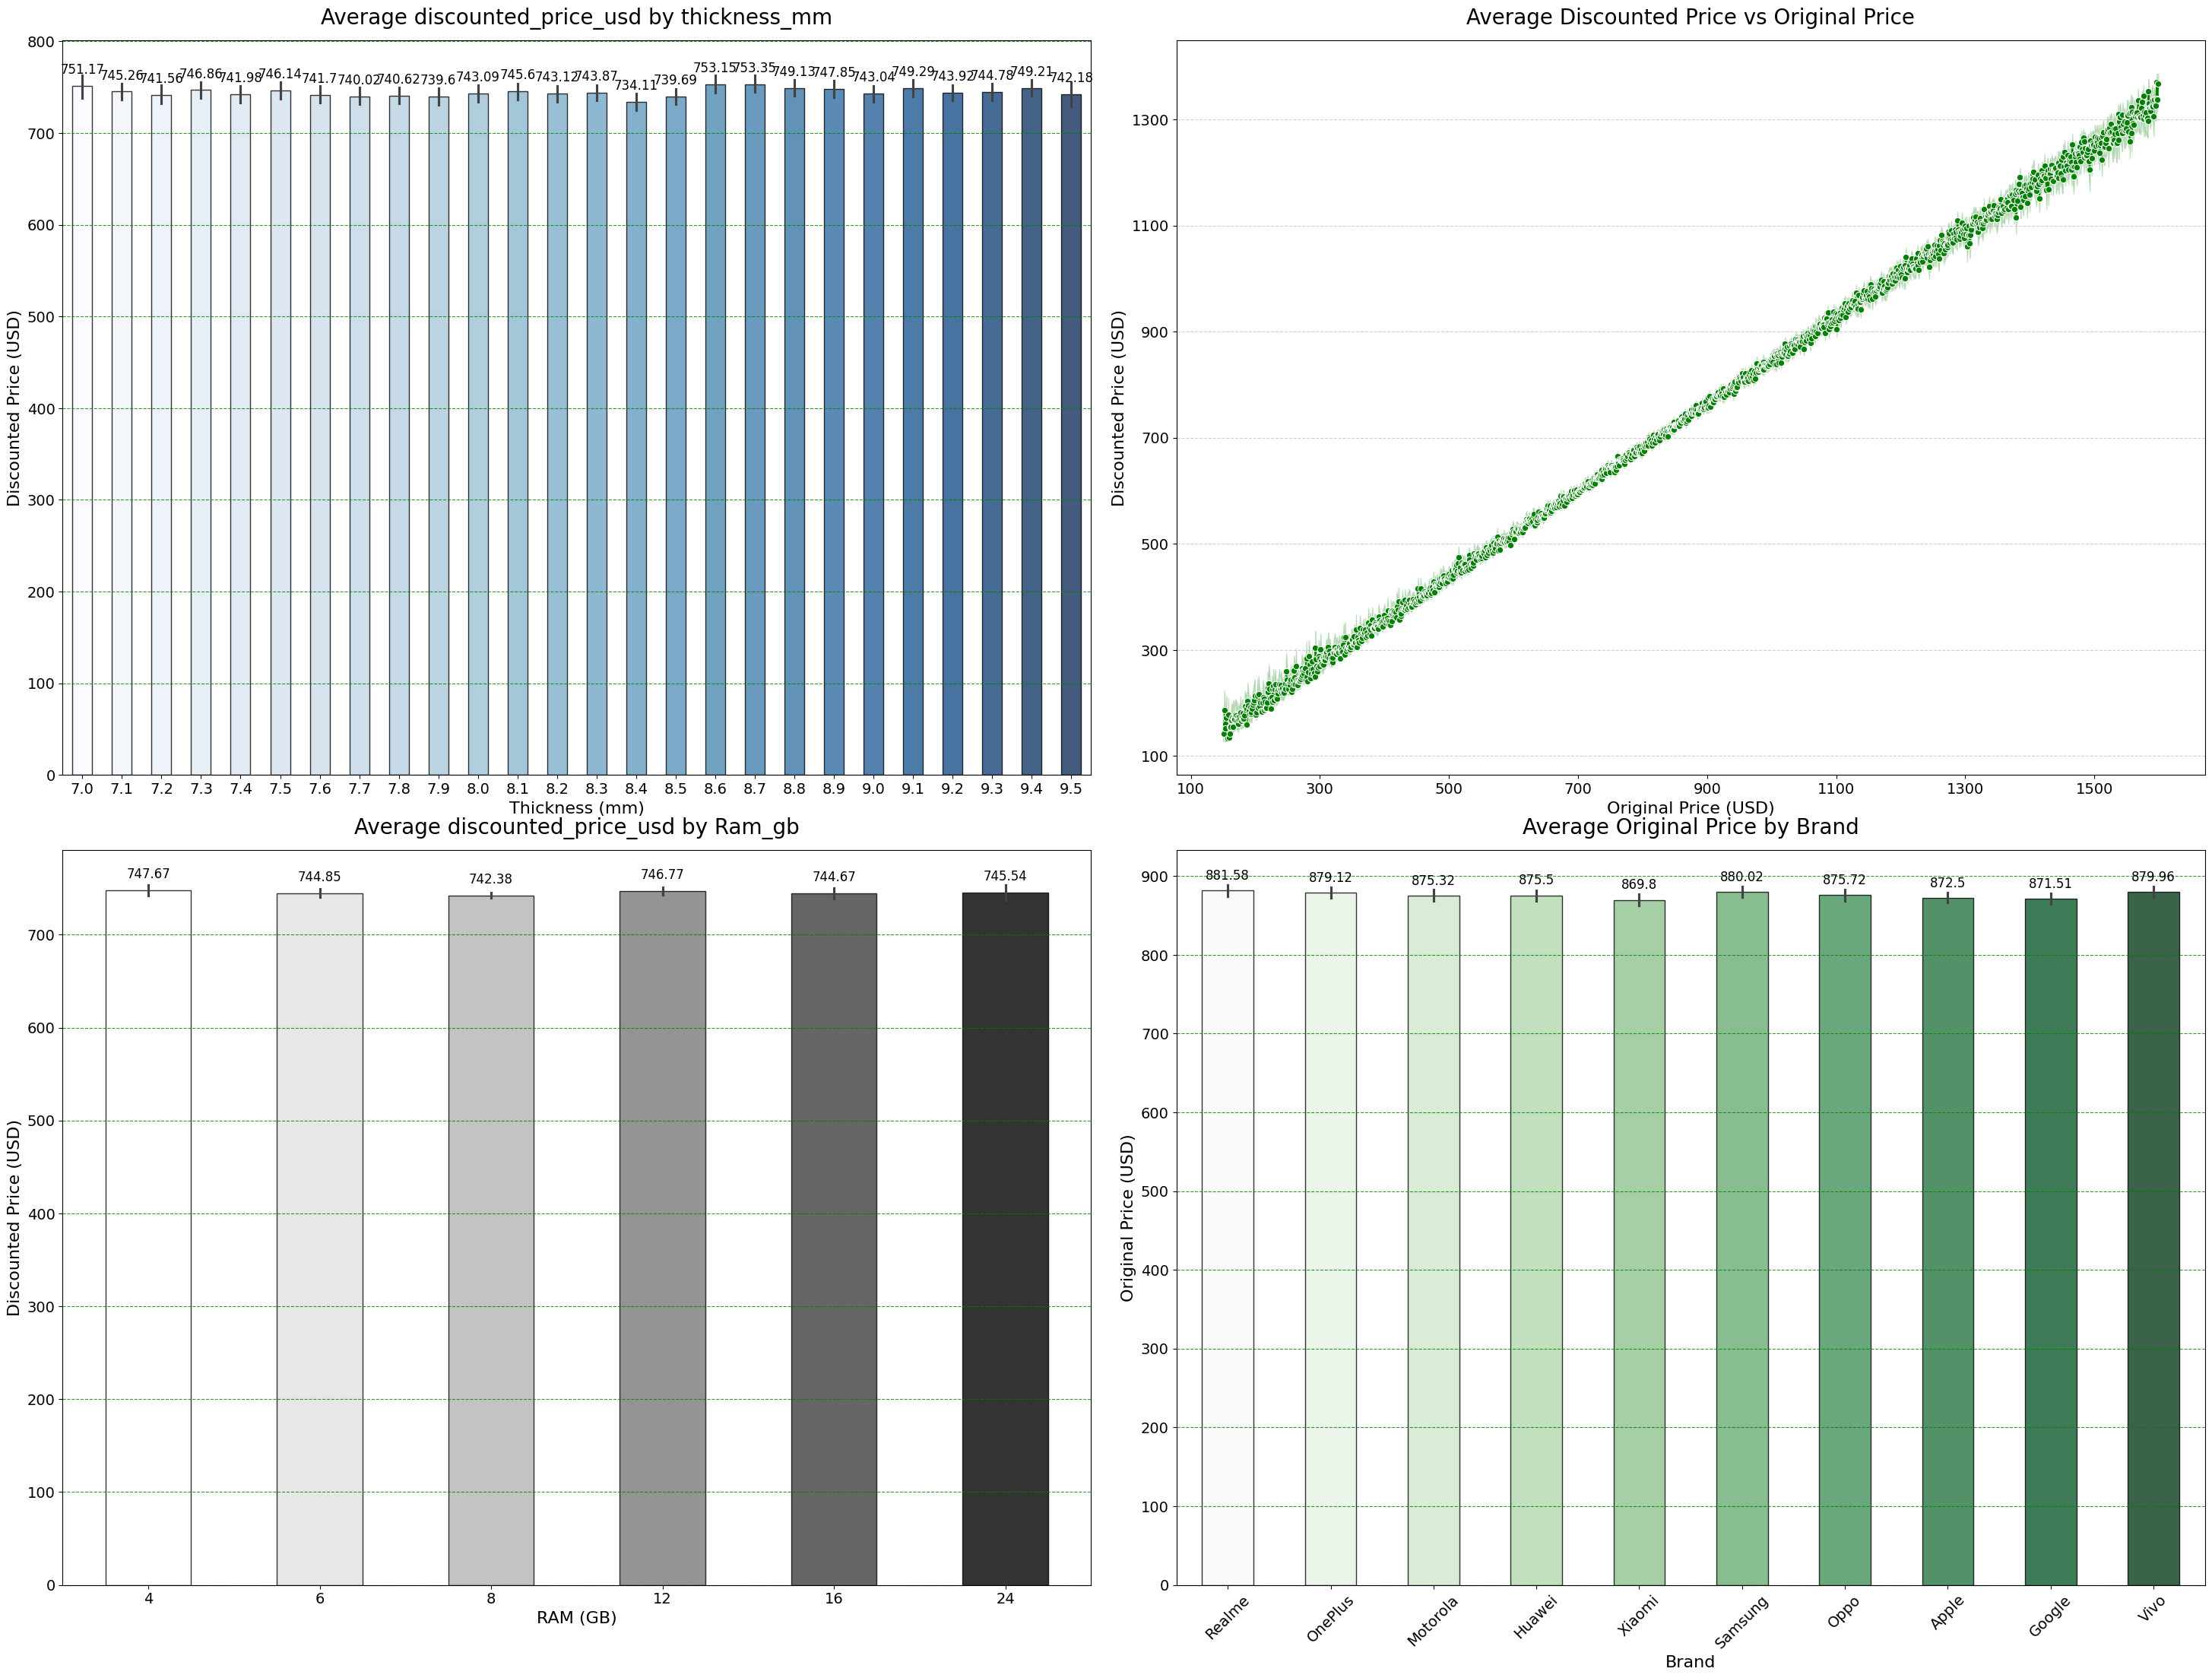

In [101]:

fig, axes = plt.subplots(2, 2, figsize=(30, 22))  # خليهم 4 رسومات (2 صف × 2 عمود)
plt.tight_layout(pad=5.0)

# subplot 1: Average discounted_price_usd by thickness_mm
ax1 = axes[0,0]
thickness = df['thickness_mm'].unique()
cmap = cm.get_cmap("Blues", len(thickness))
palette = [cmap(i) for i in range(len(thickness))]

sns.barplot(x='thickness_mm', y='discounted_price_usd', data=df, width=0.5,
            palette=palette, alpha=0.8, edgecolor='black', ax=ax1)

for p in ax1.patches:
    ax1.text(p.get_x() + p.get_width()/2, p.get_height() + 10,
             round(p.get_height(), 2), ha='center', va='bottom',
             fontsize=12, color='black')

ax1.set_title('Average discounted_price_usd by thickness_mm', fontsize=20, pad=15)
ax1.set_xlabel('Thickness (mm)', fontsize=16)
ax1.set_ylabel('Discounted Price (USD)', fontsize=16)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.8, color='green')

# subplot 2: Average Discounted Price vs Original Price
ax2 = axes[0,1]
sns.lineplot(x='original_price_usd', y='discounted_price_usd', data=df,
             estimator='mean', color='green', marker='o', ax=ax2)

ax2.set_title('Average Discounted Price vs Original Price', fontsize=20, pad=15)
ax2.set_xlabel('Original Price (USD)', fontsize=16)
ax2.set_ylabel('Discounted Price (USD)', fontsize=16)
ax2.set_xticks(range(100,1700,200))
ax2.set_yticks(range(100,1500,200))
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# subplot 3: Average discounted_price_usd by Ram_gb
ax3 = axes[1,0]
ram = df['ram_gb'].unique()
cmap = cm.get_cmap("Greys", len(ram))
palette = [cmap(i) for i in range(len(ram))]

sns.barplot(x='ram_gb', y='discounted_price_usd', data=df, width=0.5,
            palette=palette, alpha=0.8, edgecolor='black', ax=ax3)

for p in ax3.patches:
    ax3.text(p.get_x() + p.get_width()/2, p.get_height() + 10,
             round(p.get_height(), 2), ha='center', va='bottom',
             fontsize=12, color='black')

ax3.set_title('Average discounted_price_usd by Ram_gb', fontsize=20, pad=15)
ax3.set_xlabel('RAM (GB)', fontsize=16)
ax3.set_ylabel('Discounted Price (USD)', fontsize=16)
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.set_yticks(range(0,800,100))
ax3.grid(axis='y', linestyle='--', alpha=0.8, color='green')

# subplot 4: Average Original Price by Brand
ax4 = axes[1,1]
brands = df['brand'].unique()
cmap = cm.get_cmap("Greens", len(brands))
palette = [cmap(i) for i in range(len(brands))]

sns.barplot(x='brand', y='original_price_usd', data=df, width=0.5,
            palette=palette, alpha=0.8, edgecolor='black', ax=ax4)

for p in ax4.patches:
    ax4.text(p.get_x() + p.get_width()/2, p.get_height() + 10,
             round(p.get_height(), 2), ha='center', va='bottom',
             fontsize=12, color='black')

ax4.set_title('Average Original Price by Brand', fontsize=20, pad=15)
ax4.set_xlabel('Brand', fontsize=16)
ax4.set_ylabel('Original Price (USD)', fontsize=16)
ax4.tick_params(axis='x', labelsize=14, rotation=45)
ax4.tick_params(axis='y', labelsize=14)
ax4.set_yticks(range(0,950,100))
ax4.grid(axis='y', linestyle='--', alpha=0.8, color='green')

plt.show()


#### **Drop Unneeded Columns**

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144899 entries, 0 to 149679
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   brand                    144899 non-null  object 
 1   model                    144899 non-null  object 
 2   marketing_name           144899 non-null  object 
 3   release_year             144899 non-null  int64  
 4   release_month            144899 non-null  int64  
 5   operating_system         144899 non-null  object 
 6   os_version               144899 non-null  int64  
 7   5g_supported             144899 non-null  object 
 8   screen_size_inches       144899 non-null  float64
 9   screen_resolution        144899 non-null  object 
 10  refresh_rate_hz          144899 non-null  int64  
 11  panel_type               144899 non-null  object 
 12  processor_brand          144899 non-null  object 
 13  processor_model          144899 non-null  object 
 14  core_coun

In [103]:
df

,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,screen_resolution,...,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count,discounted_price_usd
0,Realme,Model_488,Lite 35078,2024,5,Android,14,Yes,5.6,FHD+,...,224,8.0,Glass/Plastic,IP53,1048,MEA,3481,5.0,14790,797.82
1,Realme,Model_686,Lite 129286,2025,12,Android,15,No,6.7,FHD+,...,223,8.2,Glass/Aluminum,IP68,1367,Europe,1008,4.8,13151,1063.94
2,OnePlus,Model_560,Pro Max 16925,2024,12,Android,14,Yes,6.3,QHD+,...,204,7.5,Titanium,IP53,909,Asia,181,3.9,10828,812.76
3,Motorola,Model_833,Lite 57363,2025,5,Android,15,Yes,6.6,FHD+,...,177,7.2,Titanium,NaN,968,MEA,4914,4.6,3598,825.46
4,Huawei,Model_261,Lite 130934,2026,12,Android,14,Yes,5.6,FHD+,...,170,7.7,Eco-Leather,IP67,1434,Asia,93,4.8,20041,1257.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149675,Oppo,Model_551,Lite 116082,2026,1,Android,17,No,6.6,FHD+,...,214,8.3,Glass/Plastic,IP53,880,Europe,3768,3.8,2020,803.03
149676,Realme,Model_451,Lite 38744,2023,5,Android,17,Yes,6.4,FHD+,...,207,8.1,Plastic,NaN,204,Global,1516,4.4,19221,153.33
149677,Google,Model_164,Lite 98971,2025,1,Android,15,Yes,5.7,FHD+,...,238,7.2,Titanium,IP67,929,Europe,891,4.5,12155,828.48
149678,Vivo,Model_552,Lite 114316,2025,7,Android,15,Yes,6.1,FHD+,...,191,7.1,Glass/Aluminum,IP67,219,Europe,1106,4.7,1197,199.81


#### **x and y**(Target and fature)

In [104]:
x= df.drop('discounted_price_usd',axis=1)
y = df ['discounted_price_usd']

In [105]:
x

,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,screen_resolution,...,wireless_charging,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count
0,Realme,Model_488,Lite 35078,2024,5,Android,14,Yes,5.6,FHD+,...,No,224,8.0,Glass/Plastic,IP53,1048,MEA,3481,5.0,14790
1,Realme,Model_686,Lite 129286,2025,12,Android,15,No,6.7,FHD+,...,No,223,8.2,Glass/Aluminum,IP68,1367,Europe,1008,4.8,13151
2,OnePlus,Model_560,Pro Max 16925,2024,12,Android,14,Yes,6.3,QHD+,...,Yes,204,7.5,Titanium,IP53,909,Asia,181,3.9,10828
3,Motorola,Model_833,Lite 57363,2025,5,Android,15,Yes,6.6,FHD+,...,No,177,7.2,Titanium,NaN,968,MEA,4914,4.6,3598
4,Huawei,Model_261,Lite 130934,2026,12,Android,14,Yes,5.6,FHD+,...,No,170,7.7,Eco-Leather,IP67,1434,Asia,93,4.8,20041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149675,Oppo,Model_551,Lite 116082,2026,1,Android,17,No,6.6,FHD+,...,No,214,8.3,Glass/Plastic,IP53,880,Europe,3768,3.8,2020
149676,Realme,Model_451,Lite 38744,2023,5,Android,17,Yes,6.4,FHD+,...,No,207,8.1,Plastic,NaN,204,Global,1516,4.4,19221
149677,Google,Model_164,Lite 98971,2025,1,Android,15,Yes,5.7,FHD+,...,No,238,7.2,Titanium,IP67,929,Europe,891,4.5,12155
149678,Vivo,Model_552,Lite 114316,2025,7,Android,15,Yes,6.1,FHD+,...,No,191,7.1,Glass/Aluminum,IP67,219,Europe,1106,4.7,1197


In [106]:
y

0          797.82
1         1063.94
2          812.76
3          825.46
4         1257.20
           ...   
149675     803.03
149676     153.33
149677     828.48
149678     199.81
149679     754.61
Name: discounted_price_usd, Length: 144899, dtype: float64

# label encoder

In [107]:
x

,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,screen_resolution,...,wireless_charging,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count
0,Realme,Model_488,Lite 35078,2024,5,Android,14,Yes,5.6,FHD+,...,No,224,8.0,Glass/Plastic,IP53,1048,MEA,3481,5.0,14790
1,Realme,Model_686,Lite 129286,2025,12,Android,15,No,6.7,FHD+,...,No,223,8.2,Glass/Aluminum,IP68,1367,Europe,1008,4.8,13151
2,OnePlus,Model_560,Pro Max 16925,2024,12,Android,14,Yes,6.3,QHD+,...,Yes,204,7.5,Titanium,IP53,909,Asia,181,3.9,10828
3,Motorola,Model_833,Lite 57363,2025,5,Android,15,Yes,6.6,FHD+,...,No,177,7.2,Titanium,NaN,968,MEA,4914,4.6,3598
4,Huawei,Model_261,Lite 130934,2026,12,Android,14,Yes,5.6,FHD+,...,No,170,7.7,Eco-Leather,IP67,1434,Asia,93,4.8,20041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149675,Oppo,Model_551,Lite 116082,2026,1,Android,17,No,6.6,FHD+,...,No,214,8.3,Glass/Plastic,IP53,880,Europe,3768,3.8,2020
149676,Realme,Model_451,Lite 38744,2023,5,Android,17,Yes,6.4,FHD+,...,No,207,8.1,Plastic,NaN,204,Global,1516,4.4,19221
149677,Google,Model_164,Lite 98971,2025,1,Android,15,Yes,5.7,FHD+,...,No,238,7.2,Titanium,IP67,929,Europe,891,4.5,12155
149678,Vivo,Model_552,Lite 114316,2025,7,Android,15,Yes,6.1,FHD+,...,No,191,7.1,Glass/Aluminum,IP67,219,Europe,1106,4.7,1197


In [108]:
df.columns

Index(['brand', 'model', 'marketing_name', 'release_year', 'release_month',
       'operating_system', 'os_version', '5g_supported', 'screen_size_inches',
       'screen_resolution', 'refresh_rate_hz', 'panel_type', 'processor_brand',
       'processor_model', 'core_count', 'ram_gb', 'storage_gb',
       'card_slot_available', 'main_camera_mp', 'num_rear_cameras',
       'front_camera_mp', 'battery_capacity_mah', 'charging_speed_w',
       'wireless_charging', 'weight_grams', 'thickness_mm', 'body_material',
       'water_resistance_rating', 'original_price_usd', 'region_market',
       'stock_availability', 'user_rating', 'review_count',
       'discounted_price_usd'],
      dtype='object')

In [109]:
encoder=LabelEncoder() 
x['brand']=encoder.fit_transform(x['brand'])
x['model']=encoder.fit_transform(x['model'])
x['marketing_name']=encoder.fit_transform(x['marketing_name'])
x['operating_system']=encoder.fit_transform(x['operating_system'])
x['5g_supported']=encoder.fit_transform(x['5g_supported'])
x['wireless_charging']=encoder.fit_transform(x['wireless_charging'])
x['body_material']=encoder.fit_transform(x['body_material'])
x['water_resistance_rating']=encoder.fit_transform(x['water_resistance_rating'])
x['region_market']=encoder.fit_transform(x['region_market'])
x['screen_resolution']=encoder.fit_transform(x['screen_resolution'])
x['region_market']=encoder.fit_transform(x['region_market'])
x['panel_type']=encoder.fit_transform(x['panel_type'])
x['processor_brand']=encoder.fit_transform(x['processor_brand'])
x['card_slot_available']=encoder.fit_transform(x['card_slot_available'])
x['processor_model']=encoder.fit_transform(x['processor_model'])






In [110]:
x

,brand,model,marketing_name,release_year,release_month,operating_system,os_version,5g_supported,screen_size_inches,screen_resolution,...,wireless_charging,weight_grams,thickness_mm,body_material,water_resistance_rating,original_price_usd,region_market,stock_availability,user_rating,review_count
0,6,388,50703,2024,5,0,14,1,5.6,1,...,0,224,8.0,2,0,1048,3,3481,5.0,14790
1,6,586,21275,2025,12,0,15,0,6.7,1,...,0,223,8.2,1,2,1367,1,1008,4.8,13151
2,4,460,108881,2024,12,0,14,1,6.3,3,...,1,204,7.5,4,0,909,0,181,3.9,10828
3,3,733,66905,2025,5,0,15,1,6.6,1,...,0,177,7.2,4,3,968,3,4914,4.6,3598
4,2,161,22481,2026,12,0,14,1,5.6,1,...,0,170,7.7,0,1,1434,0,93,4.8,20041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149675,5,451,11690,2026,1,0,17,0,6.6,1,...,0,214,8.3,2,0,880,1,3768,3.8,2020
149676,6,351,53361,2023,5,0,17,1,6.4,1,...,0,207,8.1,3,3,204,2,1516,4.4,19221
149677,1,64,97156,2025,1,0,15,1,5.7,1,...,0,238,7.2,4,1,929,1,891,4.5,12155
149678,8,452,10396,2025,7,0,15,1,6.1,1,...,0,191,7.1,1,1,219,1,1106,4.7,1197


In [111]:
y

0          797.82
1         1063.94
2          812.76
3          825.46
4         1257.20
           ...   
149675     803.03
149676     153.33
149677     828.48
149678     199.81
149679     754.61
Name: discounted_price_usd, Length: 144899, dtype: float64

#### **Data Scaling**

In [112]:
scaler=MinMaxScaler()
x=scaler.fit_transform(x)

In [113]:
x

array([[0.66666667, 0.43207127, 0.35483194, ..., 0.69633927, 1.        ,
        0.59146024],
       [0.66666667, 0.65256125, 0.14888763, ..., 0.20164033, 0.86666667,
        0.52587138],
       [0.44444444, 0.51224944, 0.76197574, ..., 0.03620724, 0.26666667,
        0.43291048],
       ...,
       [0.11111111, 0.07126949, 0.67992134, ..., 0.17823565, 0.66666667,
        0.48601385],
       [0.88888889, 0.50334076, 0.07275374, ..., 0.22124425, 0.8       ,
        0.0475009 ],
       [0.        , 0.12694878, 0.39199961, ..., 0.97939588, 0.46666667,
        0.06979071]], shape=(144899, 33))

In [114]:
y

0          797.82
1         1063.94
2          812.76
3          825.46
4         1257.20
           ...   
149675     803.03
149676     153.33
149677     828.48
149678     199.81
149679     754.61
Name: discounted_price_usd, Length: 144899, dtype: float64

# train_test_split

In [115]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=45,test_size=0.2)

# LINEARREGRESSION,LASSO,RIDGE,SGDREGRESSOR

In [116]:
lr=LinearRegression(fit_intercept=False,positive=False)
lr.fit(x_train,y_train)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [117]:
lr.score(x_train,y_train)

0.9324126635388266

In [118]:
lr.score(x_test,y_test)

0.9343033083738871

In [119]:
y_pred=lr.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

57.57452791496638


In [120]:
y_pred=lr.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

57.021592757519


In [121]:
lasso=Lasso(max_iter=1000,alpha=0,tol=0.00001)
lasso.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.717e+08, tolerance: 1.443e+05
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in 

,alpha,0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,1e-05
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [122]:
lasso.score(x_train,y_train)

0.9346219861661091

In [123]:
lasso.score(x_test,y_test)

0.9365812088240194

In [124]:
y_pred=lasso.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

56.60397039457481


In [125]:
y_pred=lasso.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

55.96562135315392


In [126]:
ridge=Ridge(alpha=0,max_iter=1000,tol=0)
ridge.fit(x_train,y_train)

,alpha,0
,fit_intercept,True
,copy_X,True
,max_iter,1000
,tol,0
,solver,'auto'
,positive,False
,random_state,None


In [127]:
ridge.score(x_train,y_train)

0.9346219861661091

In [128]:
ridge.score(x_test,y_test)

0.9365812088240194

In [129]:
y_pred=ridge.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

56.60397039457385


In [130]:
y_pred=ridge.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

55.96562135315295


# neighbour

In [131]:
neighbour=KNeighborsRegressor(n_neighbors=12,leaf_size=10,weights='distance',n_jobs=15)
neighbour.fit(x_train,y_train)

,n_neighbors,12
,weights,'distance'
,algorithm,'auto'
,leaf_size,10
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,15


In [132]:
neighbour.score(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 

0.9989191015597985

In [133]:
neighbour.score(x_test,y_test)

0.6250709810130102

In [134]:
y_pred=neighbour.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.6561940104794658


In [135]:
y_pred=neighbour.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

178.81133106405133


# tree

In [136]:
tree=DecisionTreeRegressor(splitter='random',min_samples_split=50,min_samples_leaf=10)
tree.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'random'
,max_depth,None
,min_samples_split,50
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [137]:
tree.score(x_train,y_train)

0.9438066218575112

In [138]:
tree.score(x_test,y_test)

0.9274894239890237

In [139]:
y_pred=tree.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

53.18016205132443


In [140]:
y_pred=tree.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

61.089731752747745


  RandomForestRegressor,BaggingRegressor,ExtraTreesRegressor

In [141]:
rf=RandomForestRegressor(n_estimators=500,min_samples_split=20,min_samples_leaf=5,max_features=5)
rf.fit(x_train,y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,20
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [142]:
rf.score(x_train,y_train)

0.942155532805534

In [143]:
rf.score(x_test,y_test)

0.9112526405910524

In [144]:
y_pred=rf.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

61.6963400168094


In [145]:
y_pred=rf.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

77.24059568204902


In [146]:
bag=BaggingRegressor()
bag.fit(x_train,y_train)

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [147]:
bag.score(x_train,y_train)

0.9857100540386213

In [148]:
bag.score(x_test,y_test)

0.925912087133648

In [149]:
y_pred=bag.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

25.212139980695333


In [150]:
y_pred=bag.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

62.33542770761444


In [151]:
extra=ExtraTreesRegressor()
extra.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [152]:
extra.score(x_train,y_train)

0.9989191015598315

In [153]:
extra.score(x_test,y_test)

0.9316080943943823

In [154]:
y_pred=extra.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

0.6561622339746465


In [155]:
y_pred=extra.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

58.70161017080746


# XGBRegressor

In [156]:
xgb=XGBRegressor()
xgb.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [157]:
xgb.score(x_train,y_train)

0.9482036990372008

In [158]:
xgb.score(x_test,y_test)

0.9335426535807374

In [159]:
y_pred=xgb.predict(x_train)
print(mean_absolute_error(y_pred,y_train))

52.12061825753681


In [160]:
y_pred=xgb.predict(x_test)
print(mean_absolute_error(y_pred,y_test))

57.62617180881539


# Deep learning

In [161]:
print(x_train.shape)


(115919, 33)


In [162]:
model = Sequential([
    Dense(192, activation='relu', input_dim=33),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='linear'),])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_absolute_error', metrics=['mae'])


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [163]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 192)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,545 (166.19 KB)

 Trainable params: 42,545 (166.19 KB)

 Non-trainable params: 0 (0.00 B)

In [164]:
earlystop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
reducelr=ReduceLROnPlateau(monitor='val_loss',patience=8,factor=0.1)
logger=CSVLogger('file.csv')
weight=ModelCheckpoint('weight.h5')

In [165]:
model.fit(x_train, y_train, epochs=80,validation_split=0.3,callbacks=[earlystop,reducelr,logger,weight])

Epoch 1/80
2519/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 177.4909 - mae: 177.4909

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 90.3416 - mae: 90.3416 - val_loss: 55.1590 - val_mae: 55.1590 - learning_rate: 0.0010
Epoch 2/80
2534/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 57.9643 - mae: 57.9643

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 57.8944 - mae: 57.8944 - val_loss: 54.9188 - val_mae: 54.9188 - learning_rate: 0.0010
Epoch 3/80
2507/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 58.4774 - mae: 58.4774

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 57.8921 - mae: 57.8921 - val_loss: 54.7661 - val_mae: 54.7661 - learning_rate: 0.0010
Epoch 4/80
2534/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 57.4169 - mae: 57.4169

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 57.5183 - mae: 57.5183 - val_loss: 55.8349 - val_mae: 55.8349 - learning_rate: 0.0010
Epoch 5/80
2523/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 57.9632 - mae: 57.9632

...

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 54.6957 - mae: 54.6957 - val_loss: 54.6818 - val_mae: 54.6818 - learning_rate: 1.0000e-04
Epoch 26/80
2522/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54.8236 - mae: 54.8236

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 54.7167 - mae: 54.7167 - val_loss: 54.8805 - val_mae: 54.8805 - learning_rate: 1.0000e-04
Epoch 27/80
2516/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54.7620 - mae: 54.7620

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 54.6825 - mae: 54.6825 - val_loss: 54.6941 - val_mae: 54.6941 - learning_rate: 1.0000e-04
Epoch 28/80
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54.5023 - mae: 54.5023

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 54.4405 - mae: 54.4405 - val_loss: 54.6236 - val_mae: 54.6236 - learning_rate: 1.0000e-05
Epoch 29/80
2518/2536 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53.7061 - mae: 53.7061

2536/2536 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 54.4240 - mae: 54.4240 - val_loss: 54.6676 - val_mae: 54.6676 - learning_rate: 1.0000e-05


In [166]:
model.evaluate(x_train,y_train)

3623/3623 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 54.6128 - mae: 54.6128


[54.61281967163086, 54.61281967163086]

In [167]:
model.evaluate(x_test,y_test)

906/906 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 54.4933 - mae: 54.4933


[54.49327850341797, 54.49327850341797]